# Data Preprocessing

## 1. Load Datase and Inspect

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT)
)

In [3]:
from src.data.ingestion import load_raw_data
from src.data.preprocessing import preprocess_data
from src.data.validation import validate_dataset

In [4]:
#Load the dataset using your new ingestion module 
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

df = load_raw_data(
    RAW_DATA_PATH
)

print(
    "Raw dataset shape:",
    df.shape
)

Raw dataset shape: (2075259, 9)


In [5]:
# Find the project root correctly
PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\sayum\Desktop\smartenergy-ai


In [6]:
# Define the path to the raw data file
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

print("Raw data path:")
print(RAW_DATA_PATH)

Raw data path:
c:\Users\sayum\Desktop\smartenergy-ai\data\raw\household_power_consumption.txt


In [7]:
# Check that the file exists
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {RAW_DATA_PATH}"
    )

print("Dataset found successfully.")

Dataset found successfully.


In [8]:
# Load the raw dataset
df = pd.read_csv(
    RAW_DATA_PATH,
    sep=";",
    low_memory=False
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [9]:
# Inspect the first records

display(df.head()) # Inspect the first records
display(df.tail()) # Inspect the last records
display(df.head().T) # Transpose the first few records for better readability

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0
2075258,26/11/2010,21:02:00,0.932,0.000,239.550,3.800,0.000,0.000,0.0


,0,1,2,3,4
Date,16/12/2006,16/12/2006,16/12/2006,16/12/2006,16/12/2006
Time,17:24:00,17:25:00,17:26:00,17:27:00,17:28:00
Global_active_power,4.216,5.360,5.374,5.388,3.666
Global_reactive_power,0.418,0.436,0.498,0.502,0.528
Voltage,234.840,233.630,233.290,233.740,235.680
Global_intensity,18.400,23.000,23.000,23.000,15.800
Sub_metering_1,0.000,0.000,0.000,0.000,0.000
Sub_metering_2,1.000,1.000,2.000,1.000,1.000
Sub_metering_3,17.0,16.0,17.0,17.0,17.0


In [10]:
# Check the dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2075259
Number of columns: 9


In [11]:
print("Columns:") 
for column in df.columns:
    print(f" - {column}")

Columns:
 - Date
 - Time
 - Global_active_power
 - Global_reactive_power
 - Voltage
 - Global_intensity
 - Sub_metering_1
 - Sub_metering_2
 - Sub_metering_3


In [12]:
# Check data types
print(df.dtypes)  # The raw dataset needs preprocessing.

Date                         str
Time                         str
Global_active_power          str
Global_reactive_power        str
Voltage                      str
Global_intensity             str
Sub_metering_1               str
Sub_metering_2               str
Sub_metering_3           float64
dtype: object


## 2. MISSING VALUES

In [13]:
# Missing-value report
missing_count = df.isna().sum()

missing_percentage = (
    df.isna().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

display(
    missing_report.sort_values(
        "missing_percentage",
        ascending=False
    )
)

,missing_count,missing_percentage
Sub_metering_3,25979,1.25
Date,0,0.00
Time,0,0.00
Global_reactive_power,0,0.00
Global_active_power,0,0.00
Voltage,0,0.00
Global_intensity,0,0.00
Sub_metering_1,0,0.00
Sub_metering_2,0,0.00


In [14]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## 3. Create timestamp

In [15]:
df["timestamp"] = pd.to_datetime( 
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

C:\Users\sayum\AppData\Local\Temp\ipykernel_19344\2845618200.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(


In [16]:
# Display the first 10 rows of the DataFrame with the new timestamp column
display(
    df[
        ["Date", "Time", "timestamp"]
    ].head(10)
)

,Date,Time,timestamp
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00
5,16/12/2006,17:29:00,2006-12-16 17:29:00
6,16/12/2006,17:30:00,2006-12-16 17:30:00
7,16/12/2006,17:31:00,2006-12-16 17:31:00
8,16/12/2006,17:32:00,2006-12-16 17:32:00
9,16/12/2006,17:33:00,2006-12-16 17:33:00


## 4. Check invalid timestamps

In [17]:

invalid_timestamp_count = df["timestamp"].isna().sum()

print(
    "Invalid timestamps:",
    invalid_timestamp_count
)

Invalid timestamps: 0


## 5. Convert measurement columns

In [18]:
# List of columns to convert to numeric type
NUMERIC_COLUMNS = [ 
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

In [19]:
# Convert columns to numeric type
for column in NUMERIC_COLUMNS: 
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )
print(df[NUMERIC_COLUMNS].dtypes)

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


## 6. Check missing values again

In [20]:
missing_count = df.isna().sum()

missing_percentage = (
    df.isna().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

display(
    missing_report.sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percentage
Global_reactive_power,25979,1.25
Global_active_power,25979,1.25
Sub_metering_1,25979,1.25
Sub_metering_2,25979,1.25
Voltage,25979,1.25
Global_intensity,25979,1.25
Sub_metering_3,25979,1.25
Date,0,0.00
Time,0,0.00
timestamp,0,0.00


## 7. Check numeric statistics

In [21]:
display(
    df[NUMERIC_COLUMNS].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


## 8. Sort chronologically

In [22]:
# Sort the DataFrame by timestamp
df = df.sort_values( 
    "timestamp"
).reset_index(drop=True)

In [23]:
# Check if the timestamp column is sorted
print(
    "Timestamp sorted:",
    df["timestamp"].is_monotonic_increasing
)

Timestamp sorted: True


In [24]:
# Check duplicate timestamps
timestamp_duplicate_count = (
    df["timestamp"].duplicated().sum()
)

print(
    "Duplicate timestamps:",
    timestamp_duplicate_count
)

Duplicate timestamps: 0


## 9. Check the time range

In [25]:
print(
    "First timestamp:",
    df["timestamp"].min()
)

print(
    "Last timestamp:",
    df["timestamp"].max()
)

First timestamp: 2006-12-16 17:24:00
Last timestamp: 2010-11-26 21:02:00


In [26]:
# Check whether measurements are one minute apart
time_diff = df["timestamp"].diff()

display(
    time_diff.value_counts().head(10)
)

timestamp
0 days 00:01:00    2075258
Name: count, dtype: int64

In [27]:
# Check for expected 1-minute intervals
expected_interval = pd.Timedelta(minutes=1)

expected_count = (
    time_diff == expected_interval
).sum()

unexpected_count = (
    time_diff != expected_interval
).sum()

print(
    "Expected 1-minute intervals:",
    expected_count
)

print(
    "Unexpected intervals:",
    unexpected_count
)

Expected 1-minute intervals: 2075258
Unexpected intervals: 1


## 10. Find the largest time gaps

In [28]:
gap_report = (
    pd.DataFrame({
        "timestamp": df["timestamp"],
        "time_diff": time_diff
    })
    .sort_values(
        "time_diff",
        ascending=False
    )
)

display(
    gap_report.head(20)
)

,timestamp,time_diff
1,2006-12-16 17:25:00,0 days 00:01:00
1383500,2009-08-03 11:44:00,0 days 00:01:00
1383513,2009-08-03 11:57:00,0 days 00:01:00
1383512,2009-08-03 11:56:00,0 days 00:01:00
1383511,2009-08-03 11:55:00,0 days 00:01:00
1383510,2009-08-03 11:54:00,0 days 00:01:00
1383509,2009-08-03 11:53:00,0 days 00:01:00
1383508,2009-08-03 11:52:00,0 days 00:01:00
1383507,2009-08-03 11:51:00,0 days 00:01:00
1383506,2009-08-03 11:50:00,0 days 00:01:00


In [29]:
# Check negative values
for column in NUMERIC_COLUMNS:
    negative_count = (
        df[column] < 0
    ).sum()

    print(
        f"{column}: {negative_count} negative values"
    )

Global_active_power: 0 negative values
Global_reactive_power: 0 negative values
Voltage: 0 negative values
Global_intensity: 0 negative values
Sub_metering_1: 0 negative values
Sub_metering_2: 0 negative values
Sub_metering_3: 0 negative values


In [30]:
# Check zero values

for column in NUMERIC_COLUMNS:
    zero_count = (
        df[column] == 0
    ).sum()

    print(
        f"{column}: {zero_count} zero values"
    )

Global_active_power: 0 zero values
Global_reactive_power: 481561 zero values
Voltage: 0 zero values
Global_intensity: 0 zero values
Sub_metering_1: 1880175 zero values
Sub_metering_2: 1436830 zero values
Sub_metering_3: 852092 zero values


In [31]:
# Create a missing-data block analysis
df["is_missing_power"] = (
    df["Global_active_power"].isna()
)

In [32]:
df["missing_group"] = (
    df["is_missing_power"]
    != df["is_missing_power"].shift()
).cumsum()

In [33]:
missing_blocks = (
    df[df["is_missing_power"]]
    .groupby("missing_group")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_count=("timestamp", "count")
    )
    .sort_values(
        "missing_count",
        ascending=False
    )
)

In [34]:
display(
    missing_blocks.head(20)
)

,start_time,end_time,missing_count
missing_group,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70


In [35]:
print(
    "Total missing blocks:",
    len(missing_blocks)
)

Total missing blocks: 71


# 11 — Missing Data Analysis

In [36]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

display(missing_summary)

,missing_count,missing_percentage
Global_reactive_power,25979,1.251844
Global_active_power,25979,1.251844
Global_intensity,25979,1.251844
Voltage,25979,1.251844
Sub_metering_3,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_1,25979,1.251844
Time,0,0.000000
Date,0,0.000000
timestamp,0,0.000000


# 12. Calculate missing block duration

In [37]:
missing_blocks["duration"] = (
    missing_blocks["end_time"]
    - missing_blocks["start_time"]
)

missing_blocks["duration"] = (
    missing_blocks["end_time"]
    - missing_blocks["start_time"]
)

display(
    missing_blocks.head(20)
)

,start_time,end_time,missing_count,duration
missing_group,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,5 days 00:25:00
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,3 days 15:16:00
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,2 days 14:02:00
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,2 days 07:04:00
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,2 days 04:08:00
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,1 days 09:46:00
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891,0 days 14:50:00
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83,0 days 01:22:00
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70,0 days 01:09:00


# 13. Convert duration to hours

In [38]:
missing_blocks["duration_hours"] = (
    missing_blocks["duration"]
    .dt.total_seconds()
    / 3600
)
display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_hours"
        ]
    ].head(20)
)

,start_time,end_time,missing_count,duration_hours
missing_group,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,120.416667
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,87.266667
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,62.033333
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,55.066667
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,52.133333
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,33.766667
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891,14.833333
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83,1.366667
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70,1.150000


# 14. Categorize the missing blocks

In [39]:
def classify_gap(minutes):
    if minutes <= 5:
        return "very_short"
    elif minutes <= 60:
        return "short"
    elif minutes <= 1440:
        return "medium"
    else:
        return "long"
    
    

In [40]:
missing_blocks["gap_category"] = (
    missing_blocks["missing_count"]
    .apply(classify_gap)
)

In [41]:
display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_hours",
            "gap_category"
        ]
    ]
)

,start_time,end_time,missing_count,duration_hours,gap_category
missing_group,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,120.416667,long
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,87.266667,long
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,62.033333,long
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,55.066667,long
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,52.133333,long
...,...,...,...,...,...
130,2010-05-13 21:05:00,2010-05-13 21:05:00,1,0.000000,very_short
134,2010-06-29 16:53:00,2010-06-29 16:53:00,1,0.000000,very_short
132,2010-06-12 17:35:00,2010-06-12 17:35:00,1,0.000000,very_short


# 15. Count each category

In [42]:
gap_distribution = (
    missing_blocks["gap_category"]
    .value_counts()
)

display(gap_distribution)

gap_category
very_short    55
short          7
long           6
medium         3
Name: count, dtype: int64

In [43]:
missing_blocks["duration"] = (
    missing_blocks["end_time"]
    - missing_blocks["start_time"]
)

missing_blocks["duration_hours"] = (
    missing_blocks["duration"]
    .dt.total_seconds() / 3600
)

In [44]:
missing_blocks["gap_category"] = (
    missing_blocks["missing_count"]
    .apply(classify_gap)
)

display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_hours",
            "gap_category"
        ]
    ]
)

,start_time,end_time,missing_count,duration_hours,gap_category
missing_group,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,120.416667,long
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,87.266667,long
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,62.033333,long
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,55.066667,long
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,52.133333,long
...,...,...,...,...,...
130,2010-05-13 21:05:00,2010-05-13 21:05:00,1,0.000000,very_short
134,2010-06-29 16:53:00,2010-06-29 16:53:00,1,0.000000,very_short
132,2010-06-12 17:35:00,2010-06-12 17:35:00,1,0.000000,very_short


# 16. First, analyze the gap distribution

In [45]:
gap_distribution = (
    missing_blocks["gap_category"]
    .value_counts()
    .reindex(
        ["very_short", "short", "medium", "long"],
        fill_value=0
    )
)

display(gap_distribution)

gap_category
very_short    55
short          7
medium         3
long           6
Name: count, dtype: int64

In [46]:
missing_by_category = ( 
    missing_blocks
    .groupby("gap_category")["missing_count"]
    .sum()
    .reindex(
        ["very_short", "short", "medium", "long"],
        fill_value=0
    )
)

display(missing_by_category)

gap_category
very_short       76
short           212
medium         1044
long          24647
Name: missing_count, dtype: int64

# 17. Calculate the percentage of missing records by category

In [47]:
missing_by_category_percentage = (
    missing_by_category
    / df["Sub_metering_3"].isna().sum()
    * 100
)

missing_by_category_percentage = (
    missing_by_category_percentage
    .round(2)
)

display(missing_by_category_percentage)

gap_category
very_short     0.29
short          0.82
medium         4.02
long          94.87
Name: missing_count, dtype: float64

# 18. Implement the missing-data strategy

In [48]:
df_processed = df.copy()

print("Original shape:", df.shape)
print("Processing copy created:", df_processed.shape)

Original shape: (2075259, 12)
Processing copy created: (2075259, 12)


# 19. Create a missing-value flag

In [49]:
df_processed["Sub_metering_3_was_missing"] = ( # 
    df_processed["Sub_metering_3"].isna()
)
print(
    "Original missing values:",
    df_processed["Sub_metering_3_was_missing"].sum()
)

Original missing values: 25979


# 20. Create the gap ID again

In [50]:
df_processed["is_missing_sub3"] = (
    df_processed["Sub_metering_3"].isna()
)

df_processed["missing_group"] = (
    df_processed["is_missing_sub3"]
    != df_processed["is_missing_sub3"].shift()
).cumsum()

# 21. Calculate each missing block length

In [51]:
missing_block_sizes = (
    df_processed[
        df_processed["is_missing_sub3"]
    ]
    .groupby("missing_group")
    .size()
)

In [52]:
print(
    missing_block_sizes.describe()
)

count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
dtype: float64


# 22. Identify short gaps

In [53]:
SHORT_GAP_LIMIT = 60

In [54]:
short_missing_groups = (
    missing_block_sizes[
        missing_block_sizes <= SHORT_GAP_LIMIT
    ]
    .index
)

In [55]:
print(
    "Short missing groups:",
    len(short_missing_groups)
)

Short missing groups: 62


# 23.Create a mask for values we are allowed to interpolate

In [56]:
short_gap_mask = (
    df_processed["missing_group"]
    .isin(short_missing_groups)
    & df_processed["is_missing_sub3"]
)
print(
    "Values eligible for interpolation:",
    short_gap_mask.sum()
)

Values eligible for interpolation: 288


# 24. Interpolate only those short gaps

In [57]:
interpolated_sub3 = (
    df_processed["Sub_metering_3"]
    .interpolate(
        method="linear",
        limit=SHORT_GAP_LIMIT,
        limit_direction="both"
    )
)

In [58]:
df_processed.loc[
    short_gap_mask,
    "Sub_metering_3"
] = interpolated_sub3.loc[
    short_gap_mask
]

In [59]:
remaining_missing = ( 
    df_processed["Sub_metering_3"].isna().sum()
)

print(
    "Remaining Sub_metering_3 missing values:",
    remaining_missing
)

Remaining Sub_metering_3 missing values: 25691


# 25. Verify that long gaps remain missing

In [60]:
largest_group = (
    missing_block_sizes
    .sort_values(ascending=False)
    .index[0]
)

largest_gap = df_processed[
    df_processed["missing_group"] == largest_group
]

display(
    largest_gap[
        [
            "timestamp",
            "Sub_metering_3"
        ]
    ].head()
)

,timestamp,Sub_metering_3
1929818,2010-08-17 21:02:00,NaN
1929819,2010-08-17 21:03:00,NaN
1929820,2010-08-17 21:04:00,NaN
1929821,2010-08-17 21:05:00,NaN
1929822,2010-08-17 21:06:00,NaN


# 26. Remove temporary columns

In [61]:
df_processed = df_processed.drop(
    columns=[
        "is_missing_sub3",
        "missing_group"
    ]
)

# 27. Check the final data structure

In [62]:
print(
    df_processed.shape
)

print(
    df_processed.columns.tolist()
)

(2075259, 12)
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp', 'is_missing_power', 'Sub_metering_3_was_missing']


# 28. Verify the target variable

In [63]:
print(
    "Global_active_power missing:",
    df_processed["Global_active_power"].isna().sum()
)

Global_active_power missing: 25979


In [64]:
print("Missing values after numeric conversion:")
display(
    df[NUMERIC_COLUMNS].isna().sum()
)

Missing values after numeric conversion:


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [65]:
missing_after_conversion = (
    df[NUMERIC_COLUMNS]
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_after_conversion["missing_percentage"] = (
    missing_after_conversion["missing_count"]
    / len(df)
    * 100
)

display(
    missing_after_conversion
    .sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percentage
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


In [66]:
# Check whether all missing measurements occur together
missing_pattern = (
    df[NUMERIC_COLUMNS]
    .isna()
    .value_counts()
)

display(missing_pattern)

Global_active_power  Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3
False                False                  False    False             False           False           False             2049280
True                 True                   True     True              True            True            True                25979
Name: count, dtype: int64

In [67]:
all_measurements_missing = (
    df[NUMERIC_COLUMNS]
    .isna()
    .all(axis=1)
)

print(
    "Rows where ALL measurements are missing:",
    all_measurements_missing.sum()
)

Rows where ALL measurements are missing: 25979


In [68]:
partial_missing = (
    df[NUMERIC_COLUMNS]
    .isna()
    .any(axis=1)
    &
    ~all_measurements_missing
)

print(
    "Rows with PARTIAL missing measurements:",
    partial_missing.sum()
)

Rows with PARTIAL missing measurements: 0


In [69]:
# Check the first missing period
display(
    df[
        all_measurements_missing
    ][
        [
            "timestamp",
            *NUMERIC_COLUMNS
        ]
    ].head(20)
)

,timestamp,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,2006-12-21 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,2006-12-21 11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,2006-12-30 10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,2006-12-30 10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,2007-01-14 18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61909,2007-01-28 17:13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98254,2007-02-22 22:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98255,2007-02-22 22:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142588,2007-03-25 17:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190497,2007-04-28 00:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
# Check your missing blocks again
df["Sub_metering_3"].isna()

0          False
1          False
2          False
3          False
4          False
           ...  
2075254    False
2075255    False
2075256    False
2075257    False
2075258    False
Name: Sub_metering_3, Length: 2075259, dtype: bool

In [71]:
df["all_measurements_missing"] = (
    df[NUMERIC_COLUMNS]
    .isna()
    .all(axis=1)
)

In [72]:
df["missing_group"] = (
    df["all_measurements_missing"]
    != df["all_measurements_missing"].shift()
).cumsum()

In [73]:
measurement_missing_blocks = (
    df[
        df["all_measurements_missing"]
    ]
    .groupby("missing_group")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_count=("timestamp", "count")
    )
    .sort_values(
        "missing_count",
        ascending=False
    )
)

In [74]:
display(
    measurement_missing_blocks.head(20)
)

,start_time,end_time,missing_count
missing_group,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70


In [75]:
display(
    df[NUMERIC_COLUMNS].isna().sum()
)

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [76]:
print(
    "Rows where ALL measurements are missing:",
    df[NUMERIC_COLUMNS].isna().all(axis=1).sum()
)

print(
    "Rows with PARTIAL missing measurements:",
    (
        df[NUMERIC_COLUMNS].isna().any(axis=1)
        &
        ~df[NUMERIC_COLUMNS].isna().all(axis=1)
    ).sum()
)

Rows where ALL measurements are missing: 25979
Rows with PARTIAL missing measurements: 0


In [77]:
missing_pattern = (
    df[NUMERIC_COLUMNS]
    .isna()
    .value_counts()
)

display(missing_pattern)

Global_active_power  Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3
False                False                  False    False             False           False           False             2049280
True                 True                   True     True              True            True            True                25979
Name: count, dtype: int64

In [78]:
#  Remove the previous incorrect interpolation code
interpolated_sub3 = (
    df_processed["Sub_metering_3"]
    .interpolate(method="linear")
)

In [79]:
df_processed = df.copy()

print("Processed dataset created.")
print("Shape:", df_processed.shape)

Processed dataset created.
Shape: (2075259, 13)


# 29. Create the measurement-outage flag

In [80]:
df_processed["is_measurement_missing"] = (
    df_processed[NUMERIC_COLUMNS]
    .isna()
    .all(axis=1)
)

In [81]:
print(
    "Measurement outage rows:",
    df_processed["is_measurement_missing"].sum()
)

Measurement outage rows: 25979


In [82]:
# Create a target availability flag

df_processed["target_available"] = (
    df_processed["Global_active_power"].notna()
)

In [83]:
print(
    "Target available:",
    df_processed["target_available"].sum()
)

print(
    "Target missing:",
    df_processed["target_available"].eq(False).sum()
)

Target available: 2049280
Target missing: 25979


# 30. Verify the relationship

In [84]:
print(
    "Measurement missing but target available:",
    (
        df_processed["is_measurement_missing"]
        &
        df_processed["target_available"]
    ).sum()
)

Measurement missing but target available: 0


# 31. Create the missing block information

In [85]:
df_processed["missing_group"] = (
    df_processed["is_measurement_missing"]
    != df_processed["is_measurement_missing"].shift()
).cumsum()

In [86]:
missing_blocks = (
    df_processed[
        df_processed["is_measurement_missing"]
    ]
    .groupby("missing_group")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        missing_count=("timestamp", "count")
    )
    .sort_values(
        "missing_count",
        ascending=False
    )
)

In [87]:
missing_blocks["duration_minutes"] = (
    missing_blocks["missing_count"]
)

In [88]:
missing_blocks["duration_hours"] = (
    missing_blocks["duration_minutes"] / 60
)

In [89]:
display(
    missing_blocks.head(20)
)

,start_time,end_time,missing_count,duration_minutes,duration_hours
missing_group,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,7226,120.433333
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,5237,87.283333
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,3723,62.050000
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,3305,55.083333
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,3129,52.150000
126,2010-03-20 03:52:00,2010-03-21 13:38:00,2027,2027,33.783333
104,2009-08-13 05:00:00,2009-08-13 19:50:00,891,891,14.850000
32,2007-07-15 16:49:00,2007-07-15 18:11:00,83,83,1.383333
78,2008-12-10 10:48:00,2008-12-10 11:57:00,70,70,1.166667


# 32. Create a gap category

In [90]:
def classify_gap(minutes):
    if minutes <= 5:
        return "very_short"
    elif minutes <= 60:
        return "short"
    elif minutes <= 1440:
        return "medium"
    else:
        return "long"

In [91]:
missing_blocks["gap_category"] = (
    missing_blocks["duration_minutes"]
    .apply(classify_gap)
)

In [92]:
display(
    missing_blocks[
        [
            "start_time",
            "end_time",
            "missing_count",
            "duration_minutes",
            "duration_hours",
            "gap_category"
        ]
    ]
)

,start_time,end_time,missing_count,duration_minutes,duration_hours,gap_category
missing_group,,,,,,
138,2010-08-17 21:02:00,2010-08-22 21:27:00,7226,7226,120.433333,long
140,2010-09-25 03:56:00,2010-09-28 19:12:00,5237,5237,87.283333,long
14,2007-04-28 00:21:00,2007-04-30 14:23:00,3723,3723,62.050000,long
100,2009-06-13 00:30:00,2009-06-15 07:34:00,3305,3305,55.083333,long
118,2010-01-12 14:53:00,2010-01-14 19:01:00,3129,3129,52.150000,long
...,...,...,...,...,...,...
130,2010-05-13 21:05:00,2010-05-13 21:05:00,1,1,0.016667,very_short
134,2010-06-29 16:53:00,2010-06-29 16:53:00,1,1,0.016667,very_short
132,2010-06-12 17:35:00,2010-06-12 17:35:00,1,1,0.016667,very_short


# 33. Create a missing-data summary

In [93]:
missing_summary = {
    "total_rows": len(df_processed),
    "complete_measurement_rows": int(
        (~df_processed["is_measurement_missing"]).sum()
    ),
    "measurement_outage_rows": int(
        df_processed["is_measurement_missing"].sum()
    ),
    "measurement_outage_percentage": round(
        df_processed["is_measurement_missing"].mean() * 100,
        2
    ),
    "missing_blocks": len(missing_blocks),
    "target": "Global_active_power"
}

missing_summary

{'total_rows': 2075259,
 'complete_measurement_rows': 2049280,
 'measurement_outage_rows': 25979,
 'measurement_outage_percentage': np.float64(1.25),
 'missing_blocks': 71,
 'target': 'Global_active_power'}

# 34. Now remove only the temporary grouping column

In [94]:
df_processed.drop(
    columns=["missing_group"],
    inplace=True
)

In [95]:
# Verify the processed dataset
print("========== FINAL DATA CHECK ==========")

print("Rows:", len(df_processed))

print(
    "Columns:",
    len(df_processed.columns)
)

print(
    "Measurement outage rows:",
    df_processed["is_measurement_missing"].sum()
)

print(
    "Target missing:",
    df_processed["Global_active_power"].isna().sum()
)

print(
    "Duplicate timestamps:",
    df_processed["timestamp"].duplicated().sum()
)

print(
    "Timestamp sorted:",
    df_processed["timestamp"].is_monotonic_increasing
)

print(
    "Invalid timestamps:",
    df_processed["timestamp"].isna().sum()
)

========== FINAL DATA CHECK ==========
Rows: 2075259
Columns: 14
Measurement outage rows: 25979
Target missing: 25979
Duplicate timestamps: 0
Timestamp sorted: True
Invalid timestamps: 0


In [96]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "data_quality"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [97]:
missing_blocks.to_csv(
    RESULTS_DIR / "missing_blocks.csv"
)

In [98]:
print(
    "Missing-block report saved to:",
    RESULTS_DIR / "missing_blocks.csv"
)

Missing-block report saved to: c:\Users\sayum\Desktop\smartenergy-ai\results\data_quality\missing_blocks.csv


In [99]:
import json

In [100]:
validation_summary = {
    "dataset": "household_power_consumption",
    "total_rows": int(len(df_processed)),
    "total_columns": int(len(df_processed.columns)),
    "complete_measurement_rows": int(
        (~df_processed["is_measurement_missing"]).sum()
    ),
    "measurement_outage_rows": int(
        df_processed["is_measurement_missing"].sum()
    ),
    "measurement_outage_percentage": round(
        df_processed["is_measurement_missing"].mean() * 100,
        2
    ),
    "missing_blocks": int(len(missing_blocks)),
    "duplicate_timestamps": int(
        df_processed["timestamp"].duplicated().sum()
    ),
    "invalid_timestamps": int(
        df_processed["timestamp"].isna().sum()
    ),
    "target": "Global_active_power"
}

In [101]:
with open(
    RESULTS_DIR / "validation_summary.json",
    "w"
) as file:
    json.dump(
        validation_summary,
        file,
        indent=4
    )

In [102]:
# Run the preprocessing pipeline
df_processed = preprocess_data(df)

In [103]:
print(
    "Processed dataset shape:",
    df_processed.shape
)

Processed dataset shape: (2075259, 15)


In [104]:
# Run validation
validation_results = validate_dataset(
    df_processed
)

validation_results

{'rows': 2075259,
 'columns': 15,
 'invalid_timestamps': 0,
 'duplicate_timestamps': 0,
 'timestamp_sorted': True,
 'measurement_outage_rows': 25979,
 'measurement_outage_percentage': np.float64(1.25),
 'target_missing': 25979}

In [105]:
# Important test
assert validation_results["invalid_timestamps"] == 0

assert validation_results["duplicate_timestamps"] == 0

assert validation_results["timestamp_sorted"] is True

assert validation_results["measurement_outage_rows"] == 25979

assert validation_results["target_missing"] == 25979

print("All validation assertions passed.")

All validation assertions passed.


# 36. Processed Dataset + Automated Data Quality Tests

In [106]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [107]:
PROCESSED_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_clean.parquet"
)

In [108]:
df_processed.to_parquet(
    PROCESSED_PATH,
    index=False
)

print(
    "Processed dataset saved to:"
)
print(PROCESSED_PATH)

Processed dataset saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_clean.parquet


In [109]:
import pyarrow as pa

print("PyArrow version:", pa.__version__)

PyArrow version: 25.0.1


In [110]:
df_processed.to_parquet(
    PROCESSED_PATH,
    index=False
)

print("Processed dataset saved to:")
print(PROCESSED_PATH)

Processed dataset saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_clean.parquet


In [111]:
df_check = pd.read_parquet(
    PROCESSED_PATH
)

print(
    "Reloaded shape:",
    df_check.shape
)

Reloaded shape: (2075259, 15)


In [112]:
# Verify the data types survived
print(df_check.dtypes)

Date                                   str
Time                                   str
Global_active_power                float64
Global_reactive_power              float64
Voltage                            float64
Global_intensity                   float64
Sub_metering_1                     float64
Sub_metering_2                     float64
Sub_metering_3                     float64
timestamp                   datetime64[us]
is_missing_power                      bool
missing_group                        int64
all_measurements_missing              bool
is_measurement_missing                bool
target_available                      bool
dtype: object


In [113]:
print("========== PROCESSED DATA CHECK ==========")

print("Rows:", len(df_check))

print(
    "Missing target:",
    df_check["Global_active_power"].isna().sum()
)

print(
    "Measurement outage rows:",
    df_check["is_measurement_missing"].sum()
)

print(
    "Duplicate timestamps:",
    df_check["timestamp"].duplicated().sum()
)

print(
    "Timestamp sorted:",
    df_check["timestamp"].is_monotonic_increasing
)

========== PROCESSED DATA CHECK ==========
Rows: 2075259
Missing target: 25979
Measurement outage rows: 25979
Duplicate timestamps: 0
Timestamp sorted: True


# 37. Create a small CSV sample

In [114]:
# This will be useful when someone clones your GitHub repository and wants to understand the dataset without downloading the complete file.
SAMPLE_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_sample.csv"
)

df_check.head(10000).to_csv(
    SAMPLE_PATH,
    index=False
)

print(
    "Sample saved:",
    SAMPLE_PATH
)

Sample saved: c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_sample.csv


In [115]:
print(df_check.shape)
print(df_check.dtypes)

(2075259, 15)
Date                                   str
Time                                   str
Global_active_power                float64
Global_reactive_power              float64
Voltage                            float64
Global_intensity                   float64
Sub_metering_1                     float64
Sub_metering_2                     float64
Sub_metering_3                     float64
timestamp                   datetime64[us]
is_missing_power                      bool
missing_group                        int64
all_measurements_missing              bool
is_measurement_missing                bool
target_available                      bool
dtype: object


# 38. Regenerate the processed dataset cleanly

In [116]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [117]:
from src.data.ingestion import load_raw_data
from src.data.preprocessing import preprocess_data
from src.data.validation import validate_dataset

In [118]:
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

df_raw = load_raw_data(RAW_DATA_PATH)

print("Raw shape:", df_raw.shape)

Raw shape: (2075259, 9)


In [119]:
# Run your reusable preprocessing pipeline
df_processed = preprocess_data(df_raw)

In [120]:
print("Processed shape:", df_processed.shape)

print("\nColumns:")
print(df_processed.columns.tolist())

Processed shape: (2075259, 12)

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp', 'is_measurement_missing', 'target_available']


In [121]:
# Validate the final dataset
validation_results = validate_dataset(
    df_processed
)

print("========== FINAL DATA VALIDATION ==========")

for key, value in validation_results.items():
    print(f"{key}: {value}")

========== FINAL DATA VALIDATION ==========
rows: 2075259
columns: 12
invalid_timestamps: 0
duplicate_timestamps: 0
timestamp_sorted: True
measurement_outage_rows: 25979
measurement_outage_percentage: 1.25
target_missing: 25979


In [122]:
# Add strong assertions
assert len(df_processed) == 2_075_259

assert validation_results[
    "invalid_timestamps"
] == 0

assert validation_results[
    "duplicate_timestamps"
] == 0

assert validation_results[
    "timestamp_sorted"
] is True

assert validation_results[
    "measurement_outage_rows"
] == 25_979

assert validation_results[
    "target_missing"
] == 25_979

print(" Final dataset validation passed.")

 Final dataset validation passed.


In [123]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [124]:
PROCESSED_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_clean.parquet"
)

In [125]:
df_processed.to_parquet(
    PROCESSED_PATH,
    index=False
)

print(
    "Processed dataset saved to:"
)

print(PROCESSED_PATH)

Processed dataset saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_clean.parquet


In [126]:
df_check = pd.read_parquet(
    PROCESSED_PATH
)

print(
    "Reloaded shape:",
    df_check.shape
)

Reloaded shape: (2075259, 12)


In [127]:
# Validate the Parquet file
print(
    "Target missing:",
    df_check[
        "Global_active_power"
    ].isna().sum()
)

print(
    "Duplicate timestamps:",
    df_check[
        "timestamp"
    ].duplicated().sum()
)

print(
    "Timestamp sorted:",
    df_check[
        "timestamp"
    ].is_monotonic_increasing
)

Target missing: 25979
Duplicate timestamps: 0
Timestamp sorted: True


In [128]:
# Check the final data types
print(df_check.dtypes)

Date                                 str
Time                                 str
Global_active_power              float64
Global_reactive_power            float64
Voltage                          float64
Global_intensity                 float64
Sub_metering_1                   float64
Sub_metering_2                   float64
Sub_metering_3                   float64
timestamp                 datetime64[us]
is_measurement_missing              bool
target_available                    bool
dtype: object


In [129]:
SAMPLE_PATH = (
    PROCESSED_DIR
    / "household_power_consumption_sample.csv"
)

df_check.head(10_000).to_csv(
    SAMPLE_PATH,
    index=False
)

print(
    "Sample saved to:"
)

print(SAMPLE_PATH)

Sample saved to:
c:\Users\sayum\Desktop\smartenergy-ai\data\processed\household_power_consumption_sample.csv


In [130]:
print(df_processed.shape)
print(df_processed.columns.tolist())
print(validation_results)

(2075259, 12)
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'timestamp', 'is_measurement_missing', 'target_available']
{'rows': 2075259, 'columns': 12, 'invalid_timestamps': 0, 'duplicate_timestamps': 0, 'timestamp_sorted': True, 'measurement_outage_rows': 25979, 'measurement_outage_percentage': np.float64(1.25), 'target_missing': 25979}


# Stage 03 — Exploratory Data Analysis

In [131]:
from src.features.build_features import build_features

In [132]:
print("hourly_df" in globals())
print("df" in globals())

False
True


In [133]:
import pandas as pd
import numpy as np

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort chronologically
df = df.sort_values("timestamp")

# Set timestamp as index temporarily
df_hourly_source = df.set_index("timestamp").copy()

# Aggregate minute-level active power into hourly average demand
hourly_df = (
    df_hourly_source["Global_active_power"]
    .resample("h")
    .mean()
    .to_frame(name="demand_kw")
)

print("Hourly shape:", hourly_df.shape)
display(hourly_df.head())

Hourly shape: (34589, 1)


,demand_kw
timestamp,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [134]:
print("Rows:", len(hourly_df))
print("Columns:", hourly_df.columns.tolist())

print(
    "Missing hourly targets:",
    hourly_df["demand_kw"].isna().sum()
)

print(
    "Start:",
    hourly_df.index.min()
)

print(
    "End:",
    hourly_df.index.max()
)

Rows: 34589
Columns: ['demand_kw']
Missing hourly targets: 421
Start: 2006-12-16 17:00:00
End: 2010-11-26 21:00:00


In [135]:
print(hourly_df.dtypes)

demand_kw    float64
dtype: object


In [136]:
print(hourly_df["demand_kw"].describe())

count    34168.000000
mean         1.091728
std          0.897619
min          0.124000
25%          0.341925
50%          0.802850
75%          1.579342
max          6.560533
Name: demand_kw, dtype: float64


In [137]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\sayum\Desktop\smartenergy-ai


In [138]:
from src.features.build_features import build_features

In [139]:
feature_df = build_features(
    hourly_df,
    target_column="demand_kw"
)

In [140]:
print("Feature dataframe shape:", feature_df.shape)

Feature dataframe shape: (34589, 33)


In [141]:
print(feature_df.columns.tolist())

['demand_kw', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_night', 'is_evening_peak', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_72h', 'lag_168h', 'rolling_mean_3h', 'rolling_std_3h', 'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_12h', 'rolling_std_12h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_48h', 'rolling_std_48h', 'rolling_mean_168h', 'rolling_std_168h']


In [142]:
display(feature_df.head(10))

,demand_kw,hour,day_of_week,day_of_month,month,week_of_year,is_weekend,is_night,is_evening_peak,hour_sin,...,rolling_mean_6h,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_48h,rolling_std_48h,rolling_mean_168h,rolling_std_168h
timestamp,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,17,5,16,12,50,1,0,0,-0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 18:00:00,3.632200,18,5,16,12,50,1,0,1,-1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 19:00:00,3.400233,19,5,16,12,50,1,0,1,-0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 20:00:00,3.268567,20,5,16,12,50,1,0,1,-0.866025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 21:00:00,3.056467,21,5,16,12,50,1,0,1,-0.707107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 22:00:00,2.200133,22,5,16,12,50,1,1,1,-0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 23:00:00,2.061600,23,5,16,12,50,1,1,0,-0.258819,...,3.296748,0.669637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-17 00:00:00,1.882467,0,6,17,12,50,1,1,0,0.000000,...,2.936533,0.652900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-17 01:00:00,3.349400,1,6,17,12,50,1,1,0,0.258819,...,2.644911,0.670557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
display(feature_df.tail(10))

,demand_kw,hour,day_of_week,day_of_month,month,week_of_year,is_weekend,is_night,is_evening_peak,hour_sin,...,rolling_mean_6h,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_48h,rolling_std_48h,rolling_mean_168h,rolling_std_168h
timestamp,,,,,,,,,,,,,,,,,,,,,
2010-11-26 12:00:00,1.490200,12,4,26,11,47,0,0,0,1.224647e-16,...,1.738939,0.668347,1.014778,0.880466,1.059428,0.789136,1.127572,0.755956,1.148740,0.852545
2010-11-26 13:00:00,1.612933,13,4,26,11,47,0,0,0,-2.588190e-01,...,1.819178,0.587116,1.114436,0.858920,1.100697,0.784479,1.125623,0.754874,1.149333,0.852749
2010-11-26 14:00:00,1.407767,14,4,26,11,47,0,0,0,-5.000000e-01,...,1.607344,0.269489,1.225431,0.826891,1.153060,0.774505,1.118371,0.748321,1.149443,0.852808
2010-11-26 15:00:00,0.876433,15,4,26,11,47,0,0,0,-7.071068e-01,...,1.508756,0.195451,1.319958,0.771124,1.199189,0.754233,1.105662,0.737828,1.148768,0.852557
2010-11-26 16:00:00,1.067933,16,4,26,11,47,0,0,0,-8.660254e-01,...,1.346500,0.251575,1.368131,0.717709,1.221832,0.735011,1.092629,0.736201,1.144325,0.852016
2010-11-26 17:00:00,1.725900,17,4,26,11,47,0,0,0,-9.659258e-01,...,1.299028,0.275858,1.430956,0.646515,1.243754,0.721570,1.096668,0.735508,1.141934,0.851661
2010-11-26 18:00:00,1.573467,18,4,26,11,47,0,0,1,-1.000000e+00,...,1.363528,0.327462,1.551233,0.538719,1.253996,0.726796,1.092230,0.730946,1.147301,0.852488
2010-11-26 19:00:00,1.659333,19,4,26,11,47,0,0,1,-9.659258e-01,...,1.377406,0.335568,1.598292,0.510975,1.227407,0.701471,1.082070,0.720507,1.150604,0.853061
2010-11-26 20:00:00,1.163700,20,4,26,11,47,0,0,1,-8.660254e-01,...,1.385139,0.342544,1.496242,0.315930,1.199443,0.668173,1.085426,0.722858,1.153042,0.853931


In [144]:
feature_missing = (
    feature_df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(feature_missing)

rolling_mean_168h    1925
rolling_std_168h     1925
rolling_mean_48h      845
rolling_std_48h       845
rolling_mean_24h      629
rolling_std_24h       629
lag_168h              589
rolling_std_12h       521
rolling_mean_12h      521
lag_72h               493
lag_48h               469
rolling_mean_6h       467
rolling_std_6h        467
lag_24h               445
rolling_std_3h        440
rolling_mean_3h       440
lag_12h               433
lag_3h                424
lag_2h                423
lag_1h                422
demand_kw             421
hour_sin                0
hour_cos                0
day_sin                 0
day_cos                 0
month                   0
day_of_month            0
day_of_week             0
hour                    0
week_of_year            0
is_weekend              0
is_night                0
is_evening_peak         0
dtype: int64

In [145]:
print(
    "Original hourly columns:",
    hourly_df.shape[1]
)

print(
    "Engineered feature columns:",
    feature_df.shape[1]
)

Original hourly columns: 1
Engineered feature columns: 33


In [146]:
print(
    feature_df[
        [
            "demand_kw",
            "lag_1h",
            "lag_24h",
            "lag_168h",
            "rolling_mean_24h",
            "rolling_std_24h"
        ]
    ].head(30)
)

                     demand_kw    lag_1h   lag_24h  lag_168h  \
timestamp                                                      
2006-12-16 17:00:00   4.222889       NaN       NaN       NaN   
2006-12-16 18:00:00   3.632200  4.222889       NaN       NaN   
2006-12-16 19:00:00   3.400233  3.632200       NaN       NaN   
2006-12-16 20:00:00   3.268567  3.400233       NaN       NaN   
2006-12-16 21:00:00   3.056467  3.268567       NaN       NaN   
2006-12-16 22:00:00   2.200133  3.056467       NaN       NaN   
2006-12-16 23:00:00   2.061600  2.200133       NaN       NaN   
2006-12-17 00:00:00   1.882467  2.061600       NaN       NaN   
2006-12-17 01:00:00   3.349400  1.882467       NaN       NaN   
2006-12-17 02:00:00   1.587267  3.349400       NaN       NaN   
2006-12-17 03:00:00   1.662200  1.587267       NaN       NaN   
2006-12-17 04:00:00   2.215767  1.662200       NaN       NaN   
2006-12-17 05:00:00   1.996733  2.215767       NaN       NaN   
2006-12-17 06:00:00   1.303300  1.996733

In [147]:
from src.features.validate_features import validate_features

In [148]:
feature_validation = validate_features(
    feature_df,
    target_column="demand_kw"
)

print(feature_validation)

{'rows': 34589, 'columns': 33, 'duplicate_timestamps': 0, 'timestamp_sorted': True, 'target_missing': 421, 'feature_columns': 33}


In [149]:
FEATURE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "hourly_features.parquet"
)

feature_df.to_parquet(
    FEATURE_PATH,
    index=True
)

print(
    "Saved:",
    FEATURE_PATH
)

Saved: c:\Users\sayum\Desktop\smartenergy-ai\data\processed\features\hourly_features.parquet


# Stage 05 — Prepare the ML Dataset

In [150]:
# Create the model dataset
MODEL_FEATURES = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_night",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_12h",
    "lag_24h",
    "lag_48h",
    "lag_72h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "rolling_std_6h",
    "rolling_mean_12h",
    "rolling_std_12h",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_48h",
    "rolling_std_48h",
    "rolling_mean_168h",
    "rolling_std_168h",
]

TARGET = "demand_kw"

model_df = feature_df[
    MODEL_FEATURES + [TARGET]
].copy()

print("Before cleaning:", model_df.shape)

Before cleaning: (34589, 33)


In [151]:
# Remove rows with unavailable targets
model_df = model_df.dropna(
    subset=[TARGET]
)

print(
    "After removing missing targets:",
    model_df.shape
)

After removing missing targets: (34168, 33)


In [152]:
# Remove rows with incomplete engineered features
model_df = model_df.dropna(
    subset=MODEL_FEATURES
)

print(
    "Final supervised dataset:",
    model_df.shape
)

Final supervised dataset: (32656, 33)


In [153]:
print(
    "Remaining missing values:",
    model_df.isna().sum().sum()
)

Remaining missing values: 0


In [154]:
print(
    "Target missing:",
    model_df[TARGET].isna().sum()
)

Target missing: 0


In [155]:
# Verify the time range
print("Start:", model_df.index.min())
print("End:", model_df.index.max())

Start: 2006-12-23 17:00:00
End: 2010-11-26 21:00:00


In [156]:
print(
    "Number of observations:",
    len(model_df)
)

Number of observations: 32656


In [157]:
# check the frequency
time_diffs = model_df.index.to_series().diff()

print(
    time_diffs.value_counts().head(10)
)

timestamp
0 days 01:00:00     32647
9 days 14:00:00         1
7 days 02:00:00         1
9 days 07:00:00         1
7 days 15:00:00         1
9 days 05:00:00         1
8 days 10:00:00         1
12 days 00:00:00        1
10 days 16:00:00        1
Name: count, dtype: int64


In [158]:
# Create chronological split
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()

val_df = model_df.iloc[
    train_end:val_end
].copy()

test_df = model_df.iloc[
    val_end:
].copy()

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()

val_df = model_df.iloc[
    train_end:val_end
].copy()

test_df = model_df.iloc[
    val_end:
].copy()

In [159]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (22859, 33)
Validation: (4898, 33)
Test: (4899, 33)


In [160]:
# Verify the chronological boundaries
print("TRAIN")
print(
    train_df.index.min(),
    "→",
    train_df.index.max()
)

print("\nVALIDATION")
print(
    val_df.index.min(),
    "→",
    val_df.index.max()
)

print("\nTEST")
print(
    test_df.index.min(),
    "→",
    test_df.index.max()
)

TRAIN
2006-12-23 17:00:00 → 2009-09-04 13:00:00

VALIDATION
2009-09-04 14:00:00 → 2010-04-14 04:00:00

TEST
2010-04-14 05:00:00 → 2010-11-26 21:00:00


In [161]:
# Add assertions
assert train_df.index.max() < val_df.index.min()

assert val_df.index.max() < test_df.index.min()

assert train_df.index.is_monotonic_increasing

assert val_df.index.is_monotonic_increasing

assert test_df.index.is_monotonic_increasing

assert train_df[TARGET].notna().all()

assert val_df[TARGET].notna().all()

assert test_df[TARGET].notna().all()

print("All time-series split assertions passed.")

All time-series split assertions passed.


In [162]:
# Check for overlap
train_times = set(train_df.index)
val_times = set(val_df.index)
test_times = set(test_df.index)

print(
    "Train/Validation overlap:",
    len(train_times & val_times)
)

print(
    "Validation/Test overlap:",
    len(val_times & test_times)
)

print(
    "Train/Test overlap:",
    len(train_times & test_times)
)

Train/Validation overlap: 0
Validation/Test overlap: 0
Train/Test overlap: 0


In [163]:
# Create X and y
X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET]

X_val = val_df[MODEL_FEATURES]
y_val = val_df[TARGET]

X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET]

In [164]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (22859, 32)
y_train: (22859,)
X_val: (4898, 32)
y_val: (4898,)
X_test: (4899, 32)
y_test: (4899,)


In [165]:
# Check the target distribution
print("TRAIN")
print(y_train.describe())

print("\nVALIDATION")
print(y_val.describe())

print("\nTEST")
print(y_test.describe())

TRAIN
count    22859.000000
mean         1.091934
std          0.932404
min          0.124000
25%          0.323983
50%          0.772967
75%          1.584067
max          6.560533
Name: demand_kw, dtype: float64

VALIDATION
count    4898.000000
mean        1.230605
std         0.892096
min         0.195600
25%         0.391867
50%         1.075733
75%         1.752825
max         5.265533
Name: demand_kw, dtype: float64

TEST
count    4899.000000
mean        0.960942
std         0.708895
min         0.195100
25%         0.362750
50%         0.717233
75%         1.433533
max         5.626833
Name: demand_kw, dtype: float64


In [166]:
# Check for distribution shift
comparison = pd.DataFrame({
    "train": y_train.describe(),
    "validation": y_val.describe(),
    "test": y_test.describe(),
})

display(comparison)

,train,validation,test
count,22859.000000,4898.000000,4899.000000
mean,1.091934,1.230605,0.960942
std,0.932404,0.892096,0.708895
min,0.124000,0.195600,0.195100
25%,0.323983,0.391867,0.362750
50%,0.772967,1.075733,0.717233
75%,1.584067,1.752825,1.433533
max,6.560533,5.265533,5.626833


In [167]:
MODEL_FEATURES = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_night",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_12h",
    "lag_24h",
    "lag_48h",
    "lag_72h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_std_3h",
    "rolling_mean_6h",
    "rolling_std_6h",
    "rolling_mean_12h",
    "rolling_std_12h",
    "rolling_mean_24h",
    "rolling_std_24h",
    "rolling_mean_48h",
    "rolling_std_48h",
    "rolling_mean_168h",
    "rolling_std_168h",
]

TARGET = "demand_kw"

model_df = feature_df[
    MODEL_FEATURES + [TARGET]
].copy()

print("Before cleaning:", model_df.shape)

Before cleaning: (34589, 33)


In [168]:
model_df = model_df.dropna(
    subset=[TARGET]
)

model_df = model_df.dropna(
    subset=MODEL_FEATURES
)

print("Final supervised dataset:", model_df.shape)
print(
    "Remaining missing values:",
    model_df.isna().sum().sum()
)

Final supervised dataset: (32656, 33)
Remaining missing values: 0


In [169]:
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (22859, 33)
Validation: (4898, 33)
Test: (4899, 33)


In [170]:
print(
    "TRAIN:",
    train_df.index.min(),
    "→",
    train_df.index.max()
)

print(
    "VALIDATION:",
    val_df.index.min(),
    "→",
    val_df.index.max()
)

print(
    "TEST:",
    test_df.index.min(),
    "→",
    test_df.index.max()
)

TRAIN: 2006-12-23 17:00:00 → 2009-09-04 13:00:00
VALIDATION: 2009-09-04 14:00:00 → 2010-04-14 04:00:00
TEST: 2010-04-14 05:00:00 → 2010-11-26 21:00:00


In [171]:
assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()

assert train_df[TARGET].notna().all()
assert val_df[TARGET].notna().all()
assert test_df[TARGET].notna().all()

assert train_df.index.is_monotonic_increasing
assert val_df.index.is_monotonic_increasing
assert test_df.index.is_monotonic_increasing

print("All time-series split assertions passed.")

All time-series split assertions passed.


In [172]:
X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET]

X_val = val_df[MODEL_FEATURES]
y_val = val_df[TARGET]

X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (22859, 32)
X_val: (4898, 32)
X_test: (4899, 32)


# Stage 06 — Baseline Forecasting Models

In [173]:
# Create evaluation module
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

print("Current directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added to Python path.")

Current directory: c:\Users\sayum\Desktop\smartenergy-ai\notebooks
Project root: c:\Users\sayum\Desktop\smartenergy-ai
Project root added to Python path.


In [174]:
print((PROJECT_ROOT / "src").exists())
print((PROJECT_ROOT / "src" / "evaluation").exists())
print((PROJECT_ROOT / "src" / "evaluation" / "metrics.py").exists())

True
True
True


In [175]:
from src.evaluation.metrics import calculate_metrics

In [176]:
import numpy as np

test_true = np.array([1.0, 2.0, 3.0])
test_pred = np.array([1.1, 1.9, 3.2])

test_metrics = calculate_metrics(
    test_true,
    test_pred
)

print(test_metrics)

{'MAE': 0.13333333333333344, 'RMSE': np.float64(0.14142135623730964), 'MAPE': np.float64(7.2222222222222285), 'sMAPE': np.float64(7.0345424954446445), 'R2': 0.97}


In [177]:
#Baseline 1 — Previous hour
baseline_1h = X_test["lag_1h"]

metrics_1h = calculate_metrics(
    y_test,
    baseline_1h
)

print("Previous-hour baseline:")
print(metrics_1h)

Previous-hour baseline:
{'MAE': 0.38585662525879916, 'RMSE': np.float64(0.5844263160100315), 'MAPE': np.float64(46.24129109033426), 'sMAPE': np.float64(38.59750830202147), 'R2': 0.3201947714561999}


In [178]:
#Previous-day baseline
baseline_24h = X_test["lag_24h"]

metrics_24h = calculate_metrics(
    y_test,
    baseline_24h
)

print("Previous-day baseline:")
print(metrics_24h)

Previous-day baseline:
{'MAE': 0.5107910557507002, 'RMSE': np.float64(0.7577729403044422), 'MAPE': np.float64(66.8101645160948), 'sMAPE': np.float64(49.13800530994511), 'R2': -0.1428866483791189}


In [179]:
# Previous-week baseline
baseline_168h = X_test["lag_168h"]

metrics_168h = calculate_metrics(
    y_test,
    baseline_168h
)

print("Previous-week baseline:")
print(metrics_168h)

Previous-week baseline:
{'MAE': 0.5506019665834684, 'RMSE': np.float64(0.7958825831360381), 'MAPE': np.float64(76.55860343483512), 'sMAPE': np.float64(54.10431457270397), 'R2': -0.2607325776813536}


In [180]:
# Create the baseline comparison
import pandas as pd

baseline_results = pd.DataFrame([
    {
        "Model": "Previous Hour",
        **metrics_1h
    },
    {
        "Model": "Previous Day",
        **metrics_24h
    },
    {
        "Model": "Previous Week",
        **metrics_168h
    }
])

display(baseline_results)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Previous Hour,0.385857,0.584426,46.241291,38.597508,0.320195
1,Previous Day,0.510791,0.757773,66.810165,49.138005,-0.142887
2,Previous Week,0.550602,0.795883,76.558603,54.104315,-0.260733


In [181]:
best_baseline = baseline_results.loc[
    baseline_results["MAE"].idxmin()
]

print("Best baseline:")
print(best_baseline)

Best baseline:
Model    Previous Hour
MAE           0.385857
RMSE          0.584426
MAPE         46.241291
sMAPE        38.597508
R2            0.320195
Name: 0, dtype: object


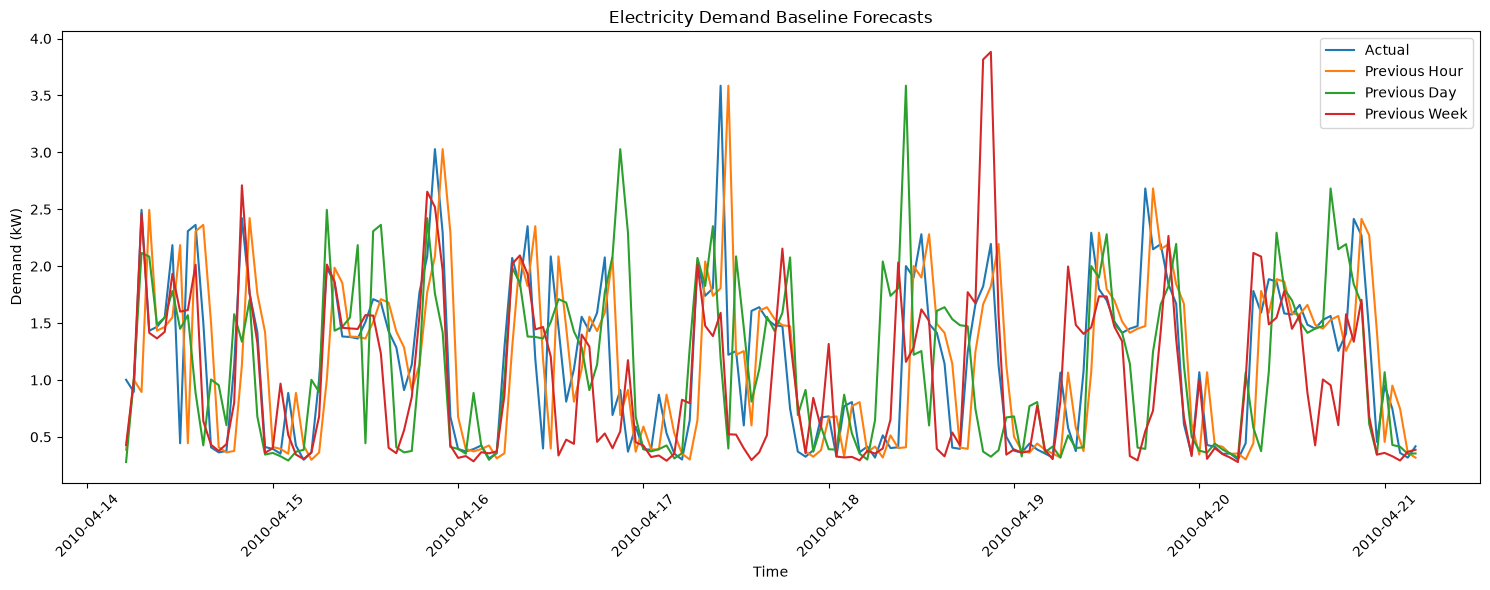

In [182]:
import matplotlib.pyplot as plt

hours_to_plot = 168

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index[:hours_to_plot],
    y_test.iloc[:hours_to_plot],
    label="Actual"
)

plt.plot(
    baseline_1h.index[:hours_to_plot],
    baseline_1h.iloc[:hours_to_plot],
    label="Previous Hour"
)

plt.plot(
    baseline_24h.index[:hours_to_plot],
    baseline_24h.iloc[:hours_to_plot],
    label="Previous Day"
)

plt.plot(
    baseline_168h.index[:hours_to_plot],
    baseline_168h.iloc[:hours_to_plot],
    label="Previous Week"
)

plt.title("Electricity Demand Baseline Forecasts")

plt.xlabel("Time")
plt.ylabel("Demand (kW)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [183]:
from src.evaluation.metrics import calculate_metrics

# Stage 07 — First ML Model

## Linear_regression

In [184]:
from src.models.linear_regression import create_linear_regression_model

In [185]:
linear_model = create_linear_regression_model()

print(linear_model)

LinearRegression()


In [186]:
linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[-0.01,-0.01,-0. ,..., 0.15, 0.13,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['hour','day_of_week','day_of_month',...,'rolling_std_48h', 'rolling_mean_168h','rolling_std_168h']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.225
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


# Generate validation prediction

In [187]:
y_val_pred_linear = linear_model.predict(
    X_val
)

In [188]:
linear_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_linear
)

print("Linear Regression - Validation")
print(linear_val_metrics)

Linear Regression - Validation
{'MAE': 0.3983950380291089, 'RMSE': np.float64(0.5656001636606101), 'MAPE': np.float64(45.094971294551094), 'sMAPE': np.float64(35.32408506132107), 'R2': 0.5979459719320225}


In [189]:
# Compare Linear Regression against the baseline

linear_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    }
])

display(linear_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946


In [190]:
from src.models.linear_regression import create_linear_regression_model

In [191]:
linear_model = create_linear_regression_model()

linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[-0.01,-0.01,-0. ,..., 0.15, 0.13,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['hour','day_of_week','day_of_month',...,'rolling_std_48h', 'rolling_mean_168h','rolling_std_168h']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.225
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


In [192]:
y_val_pred_linear = linear_model.predict(
    X_val
)

In [193]:
linear_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_linear
)

print(linear_val_metrics)

{'MAE': 0.3983950380291089, 'RMSE': np.float64(0.5656001636606101), 'MAPE': np.float64(45.094971294551094), 'sMAPE': np.float64(35.32408506132107), 'R2': 0.5979459719320225}


In [194]:
linear_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    }
])

display(linear_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946


In [195]:
# Create prediction dataframe
linear_predictions = pd.DataFrame({
    "actual": y_val.values,
    "predicted": y_val_pred_linear
})

linear_predictions["error"] = (
    linear_predictions["actual"]
    - linear_predictions["predicted"]
)

linear_predictions["absolute_error"] = (
    linear_predictions["error"].abs()
)

linear_predictions.head()

,actual,predicted,error,absolute_error
0,0.317633,0.475632,-0.157999,0.157999
1,0.645567,0.422485,0.223082,0.223082
2,0.365233,0.616056,-0.250823,0.250823
3,0.357333,0.502822,-0.145488,0.145488
4,0.316767,0.755163,-0.438396,0.438396


In [196]:
# Calculate error statistics
print(
    linear_predictions[
        ["error", "absolute_error"]
    ].describe()
)

             error  absolute_error
count  4898.000000     4898.000000
mean      0.004926        0.398395
std       0.565636        0.401519
min      -2.122002        0.000111
25%      -0.308321        0.105189
50%      -0.031577        0.273856
75%       0.223849        0.571173
max       3.844294        3.844294


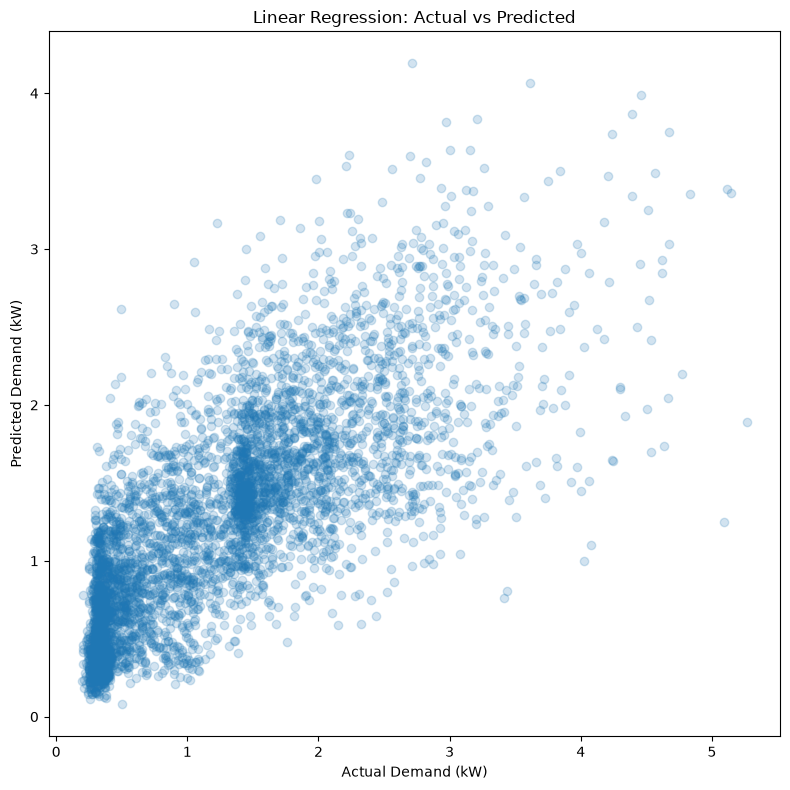

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    linear_predictions["actual"],
    linear_predictions["predicted"],
    alpha=0.2
)

plt.xlabel("Actual Demand (kW)")
plt.ylabel("Predicted Demand (kW)")
plt.title("Linear Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

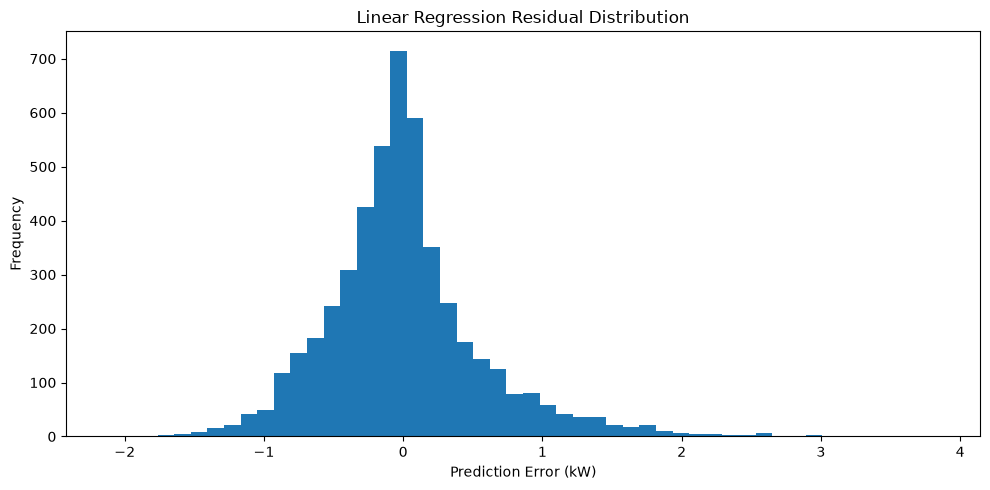

In [198]:
# Residual distribution

plt.figure(figsize=(10, 5))

plt.hist(
    linear_predictions["error"],
    bins=50
)

plt.xlabel("Prediction Error (kW)")
plt.ylabel("Frequency")
plt.title("Linear Regression Residual Distribution")

plt.tight_layout()
plt.show()

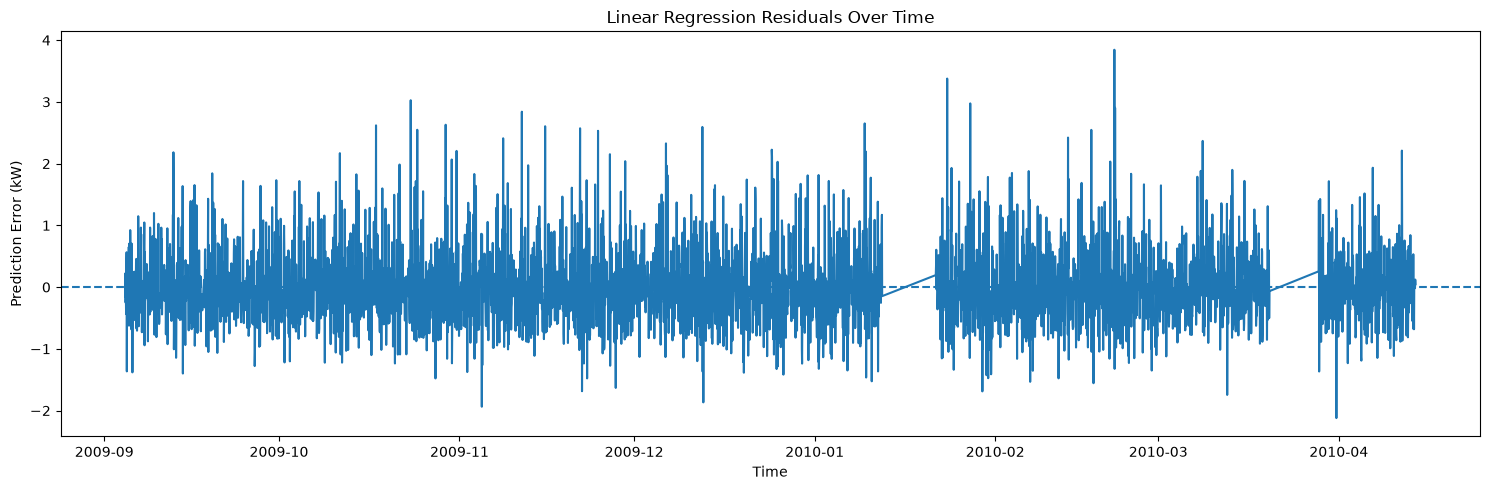

In [199]:
# Residuals over time
plt.figure(figsize=(15, 5))

plt.plot(
    y_val.index,
    linear_predictions["error"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Prediction Error (kW)")
plt.title("Linear Regression Residuals Over Time")

plt.tight_layout()
plt.show()

In [200]:
# Check performance on high-demand periods
peak_threshold = y_train.quantile(0.95)

print(
    "Training 95th percentile:",
    peak_threshold
)

Training 95th percentile: 2.9539133333333307


In [201]:
# Evaluate Linear Regression during peaks
peak_mask = y_val >= peak_threshold

print(
    "Validation peak observations:",
    peak_mask.sum()
)

print(
    "Validation peak percentage:",
    peak_mask.mean() * 100
)

Validation peak observations: 225
Validation peak percentage: 4.593711719069008


In [202]:
peak_metrics = calculate_metrics(
    y_val[peak_mask],
    y_val_pred_linear[peak_mask]
)

print("Linear Regression - Peak Performance")
print(peak_metrics)

Linear Regression - Peak Performance
{'MAE': 1.2365966408108968, 'RMSE': np.float64(1.4305480035279157), 'MAPE': np.float64(34.43314864832982), 'sMAPE': np.float64(44.44261570293517), 'R2': -6.406434017580809}


In [203]:
# Compare normal vs peak performance
normal_mask = y_val < peak_threshold

normal_metrics = calculate_metrics(
    y_val[normal_mask],
    y_val_pred_linear[normal_mask]
)

comparison = pd.DataFrame([
    {
        "Segment": "Normal Demand",
        **normal_metrics
    },
    {
        "Segment": "Peak Demand",
        **peak_metrics
    }
])

display(comparison)

,Segment,MAE,RMSE,MAPE,sMAPE,R2
0,Normal Demand,0.358037,0.486592,45.608327,34.885037,0.575344
1,Peak Demand,1.236597,1.430548,34.433149,44.442616,-6.406434


In [204]:
import joblib
from pathlib import Path

MODEL_DIR = Path(PROJECT_ROOT) / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = MODEL_DIR / "linear_regression.joblib"

joblib.dump(
    linear_model,
    model_path
)

print("Model saved to:", model_path)

Model saved to: c:\Users\sayum\Desktop\smartenergy-ai\models\linear_regression.joblib


# Stage 08 — Random Forest

In [205]:
# Import the model
from src.models.random_forest import (
    create_random_forest_model
)

In [206]:
rf_model = create_random_forest_model()

print(rf_model)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=200,
                      n_jobs=-1, random_state=42)


In [207]:
# Train Random Forest

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [208]:
# Validation predictions
y_val_pred_rf = rf_model.predict(
    X_val
)

In [209]:
rf_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_rf
)

print("Random Forest - Validation")
print(rf_val_metrics)

Random Forest - Validation
{'MAE': 0.36769003116894106, 'RMSE': np.float64(0.5340888364141884), 'MAPE': np.float64(39.91521815479279), 'sMAPE': np.float64(31.611946976615958), 'R2': 0.6414973539920095}


In [210]:
# Compare all three models

model_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    }
])

display(
    model_comparison.sort_values(
        "MAE"
    )
)

,Model,MAE,RMSE,MAPE,sMAPE,R2
2,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946
0,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951


In [211]:
rf_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    y_val_pred_rf[peak_mask]
)

print("Random Forest - Peak Performance")
print(rf_peak_metrics)

Random Forest - Peak Performance
{'MAE': 1.1299022863488573, 'RMSE': np.float64(1.329154384356299), 'MAPE': np.float64(31.3190166538742), 'sMAPE': np.float64(39.73493445805246), 'R2': -5.393742525204275}


In [212]:
peak_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **peak_metrics
    },
    {
        "Model": "Random Forest",
        **rf_peak_metrics
    }
])

display(peak_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Linear Regression,1.236597,1.430548,34.433149,44.442616,-6.406434
1,Random Forest,1.129902,1.329154,31.319017,39.734934,-5.393743


In [213]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

display(
    feature_importance.head(15)
)

,feature,importance
12,lag_1h,0.561515
19,lag_168h,0.036894
16,lag_24h,0.027159
9,hour_cos,0.024412
15,lag_12h,0.022200
6,is_night,0.021068
17,lag_48h,0.020096
18,lag_72h,0.020093
8,hour_sin,0.019650
13,lag_2h,0.019147


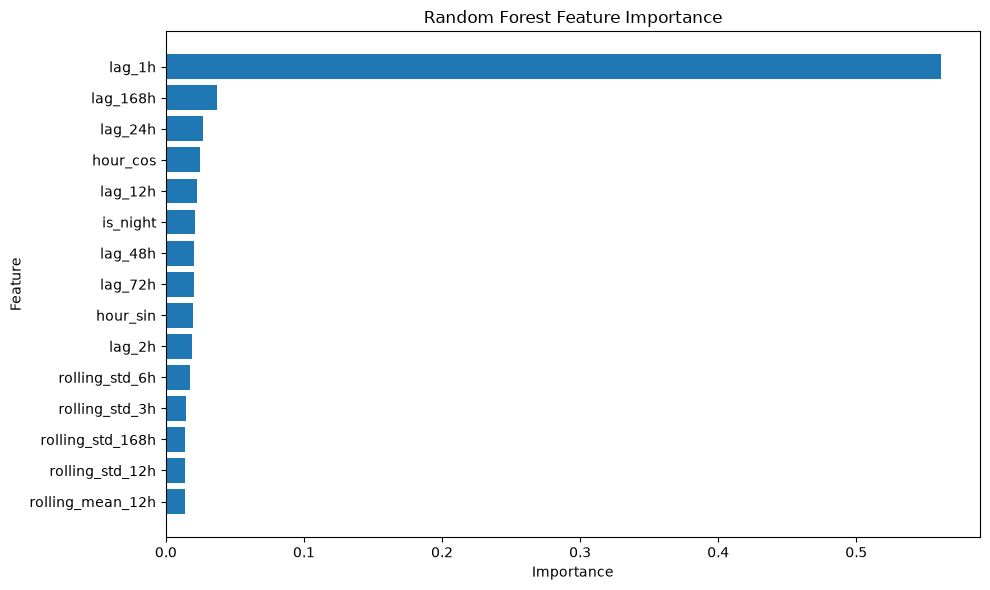

In [214]:
# Create the feature-importance chart
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [215]:
# Check Random Forest performance
print("========== RANDOM FOREST VALIDATION ==========")
print(rf_val_metrics)

========== RANDOM FOREST VALIDATION ==========
{'MAE': 0.36769003116894106, 'RMSE': np.float64(0.5340888364141884), 'MAPE': np.float64(39.91521815479279), 'sMAPE': np.float64(31.611946976615958), 'R2': 0.6414973539920095}


In [216]:
print("========== RANDOM FOREST PEAK PERFORMANCE ==========")
print(rf_peak_metrics)

========== RANDOM FOREST PEAK PERFORMANCE ==========
{'MAE': 1.1299022863488573, 'RMSE': np.float64(1.329154384356299), 'MAPE': np.float64(31.3190166538742), 'sMAPE': np.float64(39.73493445805246), 'R2': -5.393742525204275}


In [217]:
# Create the overall model comparison
model_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    }
])

model_comparison = model_comparison.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
1,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946
2,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951


In [218]:
# Compare peak performance
peak_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **peak_metrics
    },
    {
        "Model": "Random Forest",
        **rf_peak_metrics
    }
])

peak_comparison = peak_comparison.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(peak_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Random Forest,1.129902,1.329154,31.319017,39.734934,-5.393743
1,Linear Regression,1.236597,1.430548,34.433149,44.442616,-6.406434


In [219]:
from src.models.random_forest import create_random_forest_model

In [220]:
from src.models.random_forest import create_random_forest_model


def test_create_random_forest_model():
    model = create_random_forest_model()

    assert model is not None
    assert model.__class__.__name__ == "RandomForestRegressor"

# Stage 09 — XGBoost

In [221]:
from src.models.xgboost_model import create_xgboost_model
from src.evaluation.metrics import calculate_metrics

In [222]:
# Create and train XGBoost
xgb_model = create_xgboost_model()

print(xgb_model)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [223]:
y_val_pred_xgb = xgb_model.predict(X_val)

In [224]:
# Calculate validation metrics
xgb_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_xgb
)

print("========== XGBOOST VALIDATION ==========")
print(xgb_val_metrics)

========== XGBOOST VALIDATION ==========
{'MAE': 0.36729644290326413, 'RMSE': np.float64(0.530417252191028), 'MAPE': np.float64(40.03387257932272), 'sMAPE': np.float64(31.750646705904572), 'R2': 0.6464094518420191}


In [225]:
# Compare all three models

model_comparison = pd.DataFrame([
    {
        "Model": "Previous Hour Baseline",
        **calculate_metrics(
            y_val,
            X_val["lag_1h"]
        )
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    },
    {
        "Model": "XGBoost",
        **xgb_val_metrics
    }
])

model_comparison = (
    model_comparison
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

display(model_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,XGBoost,0.367296,0.530417,40.033873,31.750647,0.646409
1,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
2,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946
3,Previous Hour Baseline,0.464315,0.692123,45.414349,37.976518,0.397951


In [226]:
# Evaluate XGBoost on peak demand
peak_threshold = y_train.quantile(0.95)

peak_mask = y_val >= peak_threshold

In [227]:
xgb_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    y_val_pred_xgb[peak_mask]
)

print("========== XGBOOST PEAK PERFORMANCE ==========")
print(xgb_peak_metrics)

========== XGBOOST PEAK PERFORMANCE ==========
{'MAE': 1.1066358963623049, 'RMSE': np.float64(1.308924499365477), 'MAPE': np.float64(30.642684552324646), 'sMAPE': np.float64(38.69554093104654), 'R2': -5.2005966319685015}


In [228]:
# Compare peak performance
peak_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **peak_metrics
    },
    {
        "Model": "Random Forest",
        **rf_peak_metrics
    },
    {
        "Model": "XGBoost",
        **xgb_peak_metrics
    }
])

peak_comparison = (
    peak_comparison
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

display(peak_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,XGBoost,1.106636,1.308924,30.642685,38.695541,-5.200597
1,Random Forest,1.129902,1.329154,31.319017,39.734934,-5.393743
2,Linear Regression,1.236597,1.430548,34.433149,44.442616,-6.406434


# Stage 10 — XGBoost Hyperparameter Tuning

In [229]:
from src.models.xgboost_tuning import create_tuned_xgboost_model
from src.evaluation.metrics import calculate_metrics
import pandas as pd

In [230]:
xgb_configs = [
    {
        "name": "XGB_1",
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "XGB_2",
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "XGB_3",
        "n_estimators": 700,
        "max_depth": 6,
        "learning_rate": 0.03,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "XGB_4",
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.03,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "XGB_5",
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.02,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "XGB_6",
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    }
]

In [231]:
tuning_results = []

for config in xgb_configs:

    print(f"Training {config['name']}...")

    model = create_tuned_xgboost_model(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        min_child_weight=config["min_child_weight"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"]
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_val)

    metrics = calculate_metrics(
        y_val,
        predictions
    )

    tuning_results.append({
        "Model": config["name"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE": metrics["MAPE"],
        "sMAPE": metrics["sMAPE"],
        "R2": metrics["R2"]
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = (
    tuning_results_df
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

display(tuning_results_df)

Training XGB_1...
Training XGB_2...
Training XGB_3...
Training XGB_4...
Training XGB_5...
Training XGB_6...


,Model,MAE,RMSE,MAPE,sMAPE,R2
0,XGB_5,0.367316,0.530035,40.182214,31.704615,0.646919
1,XGB_2,0.367515,0.530866,39.999845,31.696727,0.645811
2,XGB_4,0.369016,0.532659,40.362869,31.769660,0.643414
3,XGB_1,0.369085,0.530868,40.477697,32.151940,0.645808
4,XGB_6,0.369889,0.532164,40.577132,32.042556,0.644077
5,XGB_3,0.369926,0.533588,40.463315,31.923854,0.642169


In [232]:
# Test the best configuration on peak demand
best_xgb_model = create_tuned_xgboost_model(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8
)

best_xgb_model.fit(
    X_train,
    y_train
)

best_xgb_predictions = best_xgb_model.predict(X_val)

In [233]:
peak_threshold = y_train.quantile(0.95)

peak_mask = y_val >= peak_threshold

best_xgb_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    best_xgb_predictions[peak_mask]
)

print("========== TUNED XGBOOST PEAK PERFORMANCE ==========")
print(best_xgb_peak_metrics)

========== TUNED XGBOOST PEAK PERFORMANCE ==========
{'MAE': 1.112218953414352, 'RMSE': np.float64(1.3151444350193287), 'MAPE': np.float64(30.79788004615707), 'sMAPE': np.float64(38.9442033309429), 'R2': -5.25966642084436}


In [234]:
# Train the actual XGB_5

best_xgb_model = create_tuned_xgboost_model(
    n_estimators=700,
    max_depth=8,
    learning_rate=0.02,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8
)

best_xgb_model.fit(
    X_train,
    y_train
)

best_xgb_predictions = best_xgb_model.predict(X_val)

In [235]:
peak_threshold = y_train.quantile(0.95)

peak_mask = y_val >= peak_threshold

best_xgb_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    best_xgb_predictions[peak_mask]
)

print("========== BEST TUNED XGBOOST PEAK PERFORMANCE ==========")
print(best_xgb_peak_metrics)

========== BEST TUNED XGBOOST PEAK PERFORMANCE ==========
{'MAE': 1.0999071705692434, 'RMSE': np.float64(1.3021947554886004), 'MAPE': np.float64(30.44441727328447), 'sMAPE': np.float64(38.433051194512984), 'R2': -5.137000671559209}


In [236]:
# Calculate metrics for the best tuned XGBoost model

best_xgb_metrics = calculate_metrics(
    y_val,
    best_xgb_predictions
)

print("========== BEST TUNED XGBOOST ==========")
print(best_xgb_metrics)

========== BEST TUNED XGBOOST ==========
{'MAE': 0.36731616600862166, 'RMSE': np.float64(0.5300351871648352), 'MAPE': np.float64(40.18221380168439), 'sMAPE': np.float64(31.70461505934185), 'R2': 0.6469186582317967}


In [237]:
# Final XGBoost comparison

final_xgb_comparison = pd.DataFrame([
    {
        "Model": "Original XGBoost",
        **xgb_val_metrics
    },
    {
        "Model": "Tuned XGBoost - XGB_5",
        **best_xgb_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    }
])

final_xgb_comparison = (
    final_xgb_comparison
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

display(final_xgb_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Original XGBoost,0.367296,0.530417,40.033873,31.750647,0.646409
1,Tuned XGBoost - XGB_5,0.367316,0.530035,40.182214,31.704615,0.646919
2,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
3,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946


In [238]:
# Peak demand evaluation for XGB_5

peak_threshold = y_train.quantile(0.95)

peak_mask = y_val >= peak_threshold

best_xgb_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    best_xgb_predictions[peak_mask]
)

print("========== BEST TUNED XGBOOST PEAK PERFORMANCE ==========")
print(best_xgb_peak_metrics)

========== BEST TUNED XGBOOST PEAK PERFORMANCE ==========
{'MAE': 1.0999071705692434, 'RMSE': np.float64(1.3021947554886004), 'MAPE': np.float64(30.44441727328447), 'sMAPE': np.float64(38.433051194512984), 'R2': -5.137000671559209}


In [239]:
from src.models.lightgbm_model import create_lightgbm_model
from src.evaluation.metrics import calculate_metrics

In [240]:
# ==========================================
# LIGHTGBM BASE MODEL
# ==========================================

lightgbm_model = create_lightgbm_model()

lightgbm_model.fit(
    X_train,
    y_train
)

lightgbm_predictions = lightgbm_model.predict(X_val)

lightgbm_val_metrics = calculate_metrics(
    y_val,
    lightgbm_predictions
)

print("========== LIGHTGBM VALIDATION ==========")
print(lightgbm_val_metrics)

========== LIGHTGBM VALIDATION ==========
{'MAE': 0.3676221110285676, 'RMSE': np.float64(0.5301388500632814), 'MAPE': np.float64(40.16405284751076), 'sMAPE': np.float64(31.77144209576013), 'R2': 0.6467805352717819}


In [241]:
# Compare LightGBM with your current models

lightgbm_comparison = pd.DataFrame([
    {
        "Model": "LightGBM",
        **lightgbm_val_metrics
    },
    {
        "Model": "Tuned XGBoost - XGB_5",
        **best_xgb_metrics
    },
    {
        "Model": "Original XGBoost",
        **xgb_val_metrics
    },
    {
        "Model": "Random Forest",
        **rf_val_metrics
    },
    {
        "Model": "Linear Regression",
        **linear_val_metrics
    }
])

lightgbm_comparison = (
    lightgbm_comparison
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

display(lightgbm_comparison)

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Original XGBoost,0.367296,0.530417,40.033873,31.750647,0.646409
1,Tuned XGBoost - XGB_5,0.367316,0.530035,40.182214,31.704615,0.646919
2,LightGBM,0.367622,0.530139,40.164053,31.771442,0.646781
3,Random Forest,0.367690,0.534089,39.915218,31.611947,0.641497
4,Linear Regression,0.398395,0.565600,45.094971,35.324085,0.597946


In [242]:
# ==========================================
# LIGHTGBM HYPERPARAMETER TUNING
# ==========================================

from src.models.lightgbm_tuning import create_tuned_lightgbm_model
from src.evaluation.metrics import calculate_metrics

lgbm_configs = [
    {
        "name": "LGBM_1",
        "n_estimators": 500,
        "max_depth": -1,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "LGBM_2",
        "n_estimators": 700,
        "max_depth": -1,
        "learning_rate": 0.02,
        "num_leaves": 31,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "LGBM_3",
        "n_estimators": 500,
        "max_depth": -1,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "LGBM_4",
        "n_estimators": 700,
        "max_depth": -1,
        "learning_rate": 0.02,
        "num_leaves": 63,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "LGBM_5",
        "n_estimators": 500,
        "max_depth": 12,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 30,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "name": "LGBM_6",
        "n_estimators": 700,
        "max_depth": 10,
        "learning_rate": 0.02,
        "num_leaves": 31,
        "min_child_samples": 40,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    }
]

lgbm_tuning_results = []

for config in lgbm_configs:

    print(f"Training {config['name']}...")

    model = create_tuned_lightgbm_model(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        num_leaves=config["num_leaves"],
        min_child_samples=config["min_child_samples"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"]
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_val)

    metrics = calculate_metrics(
        y_val,
        predictions
    )

    lgbm_tuning_results.append({
        "Model": config["name"],
        **metrics
    })

lgbm_tuning_results_df = pd.DataFrame(
    lgbm_tuning_results
)

lgbm_tuning_results_df = (
    lgbm_tuning_results_df
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

display(lgbm_tuning_results_df)

Training LGBM_1...
Training LGBM_2...
Training LGBM_3...
Training LGBM_4...
Training LGBM_5...
Training LGBM_6...


,Model,MAE,RMSE,MAPE,sMAPE,R2
0,LGBM_1,0.367451,0.530141,40.230252,31.809446,0.646777
1,LGBM_6,0.367726,0.531663,40.099065,31.776456,0.644746
2,LGBM_2,0.368033,0.531691,40.107383,31.753960,0.644709
3,LGBM_4,0.368520,0.532415,40.163373,31.784666,0.643740
4,LGBM_5,0.370181,0.534398,40.642544,32.004720,0.641082
5,LGBM_3,0.370213,0.535052,40.479247,31.894929,0.640203


In [243]:
# ==========================================
# BEST LIGHTGBM MODEL - LGBM_1
# ==========================================

best_lgbm_model = create_tuned_lightgbm_model(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8
)

best_lgbm_model.fit(
    X_train,
    y_train
)

best_lgbm_predictions = best_lgbm_model.predict(X_val)

best_lgbm_metrics = calculate_metrics(
    y_val,
    best_lgbm_predictions
)

print("========== BEST LIGHTGBM ==========")
print(best_lgbm_metrics)

========== BEST LIGHTGBM ==========
{'MAE': 0.3674514621577981, 'RMSE': np.float64(0.5301414758175903), 'MAPE': np.float64(40.230252220096574), 'sMAPE': np.float64(31.8094456848307), 'R2': 0.6467770363023018}


In [244]:
# ==========================================
# BEST LIGHTGBM PEAK PERFORMANCE
# ==========================================

peak_threshold = y_train.quantile(0.95)

peak_mask = y_val >= peak_threshold

best_lgbm_peak_metrics = calculate_metrics(
    y_val[peak_mask],
    best_lgbm_predictions[peak_mask]
)

print("========== BEST LIGHTGBM PEAK PERFORMANCE ==========")
print(best_lgbm_peak_metrics)

========== BEST LIGHTGBM PEAK PERFORMANCE ==========
{'MAE': 1.1058954917895618, 'RMSE': np.float64(1.3033170036080148), 'MAPE': np.float64(30.676027273390964), 'sMAPE': np.float64(38.70715409929974), 'R2': -5.14758312120922}


In [245]:
print(best_xgb_model.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.02, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 8, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 700, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [246]:
# ==========================================
# FINAL XGBOOST TEST EVALUATION
# ==========================================

final_xgb_test_predictions = best_xgb_model.predict(X_test)

final_xgb_test_metrics = calculate_metrics(
    y_test,
    final_xgb_test_predictions
)

print("========== FINAL XGBOOST TEST PERFORMANCE ==========")
print(final_xgb_test_metrics)

========== FINAL XGBOOST TEST PERFORMANCE ==========
{'MAE': 0.3165608260332491, 'RMSE': np.float64(0.4612463046582614), 'MAPE': np.float64(42.3476037638443), 'sMAPE': np.float64(33.544733067999225), 'R2': 0.5765610801509641}


In [247]:
# ==========================================
# FINAL XGBOOST TEST PEAK PERFORMANCE
# ==========================================

peak_threshold = y_train.quantile(0.95)

test_peak_mask = y_test >= peak_threshold

final_xgb_test_peak_metrics = calculate_metrics(
    y_test[test_peak_mask],
    final_xgb_test_predictions[test_peak_mask]
)

print("========== FINAL XGBOOST TEST PEAK PERFORMANCE ==========")
print(final_xgb_test_peak_metrics)

print(
    f"Peak threshold: {peak_threshold:.6f} kW"
)

print(
    f"Peak observations: {test_peak_mask.sum()}"
)

print(
    f"Peak percentage: {test_peak_mask.mean() * 100:.2f}%"
)

========== FINAL XGBOOST TEST PEAK PERFORMANCE ==========
{'MAE': 1.4337511732462878, 'RMSE': np.float64(1.5596472915096442), 'MAPE': np.float64(41.875558169052105), 'sMAPE': np.float64(55.50810885283859), 'R2': -11.25788176297659}
Peak threshold: 2.953913 kW
Peak observations: 73
Peak percentage: 1.49%


In [248]:
# Peak-demand threshold calculated from training data only
peak_threshold = y_train.quantile(0.95)

print(f"Peak threshold: {peak_threshold:.6f} kW")

# Create binary peak labels
y_train_peak = (y_train >= peak_threshold).astype(int)
y_val_peak = (y_val >= peak_threshold).astype(int)

print("\nTraining peak distribution:")
print(y_train_peak.value_counts())
print(y_train_peak.value_counts(normalize=True) * 100)

print("\nValidation peak distribution:")
print(y_val_peak.value_counts())
print(y_val_peak.value_counts(normalize=True) * 100)

Peak threshold: 2.953913 kW

Training peak distribution:
demand_kw
0    21716
1     1143
Name: count, dtype: int64
demand_kw
0    94.999781
1     5.000219
Name: proportion, dtype: float64

Validation peak distribution:
demand_kw
0    4673
1     225
Name: count, dtype: int64
demand_kw
0    95.406288
1     4.593712
Name: proportion, dtype: float64


In [249]:
from src.models.peak_classifier import create_peak_classifier

peak_classifier = create_peak_classifier()

peak_classifier.fit(
    X_train,
    y_train_peak
)

print("Peak classifier trained successfully.")

Peak classifier trained successfully.


In [250]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_val_peak_pred = peak_classifier.predict(X_val)
y_val_peak_prob = peak_classifier.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val_peak, y_val_peak_pred))
print("Precision:", precision_score(y_val_peak, y_val_peak_pred, zero_division=0))
print("Recall:", recall_score(y_val_peak, y_val_peak_pred, zero_division=0))
print("F1:", f1_score(y_val_peak, y_val_peak_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val_peak, y_val_peak_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_peak, y_val_peak_pred))

Accuracy: 0.9518170681910985
Precision: 0.44086021505376344
Recall: 0.18222222222222223
F1: 0.2578616352201258
ROC-AUC: 0.8989809068644934

Confusion Matrix:
[[4621   52]
 [ 184   41]]


In [251]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.10, 0.56, 0.05):

    y_pred = (y_val_peak_prob >= threshold).astype(int)

    precision = precision_score(
        y_val_peak,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_peak,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_peak,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results

[{'threshold': np.float64(0.1),
  'precision': 0.23293768545994065,
  'recall': 0.6977777777777778,
  'f1': 0.3492769744160178},
 {'threshold': np.float64(0.15000000000000002),
  'precision': 0.2661290322580645,
  'recall': 0.5866666666666667,
  'f1': 0.36615811373092927},
 {'threshold': np.float64(0.20000000000000004),
  'precision': 0.3002680965147453,
  'recall': 0.49777777777777776,
  'f1': 0.3745819397993311},
 {'threshold': np.float64(0.25000000000000006),
  'precision': 0.3288135593220339,
  'recall': 0.4311111111111111,
  'f1': 0.3730769230769231},
 {'threshold': np.float64(0.30000000000000004),
  'precision': 0.3656387665198238,
  'recall': 0.3688888888888889,
  'f1': 0.3672566371681416},
 {'threshold': np.float64(0.3500000000000001),
  'precision': 0.39344262295081966,
  'recall': 0.32,
  'f1': 0.35294117647058826},
 {'threshold': np.float64(0.40000000000000013),
  'precision': 0.4304635761589404,
  'recall': 0.28888888888888886,
  'f1': 0.34574468085106386},
 {'threshold': n

In [252]:
import pandas as pd

threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df.sort_values(
        "f1",
        ascending=False
    ).to_string(index=False)
)

 threshold  precision   recall       f1
      0.20   0.300268 0.497778 0.374582
      0.25   0.328814 0.431111 0.373077
      0.30   0.365639 0.368889 0.367257
      0.15   0.266129 0.586667 0.366158
      0.35   0.393443 0.320000 0.352941
      0.10   0.232938 0.697778 0.349277
      0.40   0.430464 0.288889 0.345745
      0.45   0.451613 0.248889 0.320917
      0.50   0.440860 0.182222 0.257862
      0.55   0.432836 0.128889 0.198630


In [253]:
# Freeze the classifier threshold

PEAK_CLASSIFICATION_THRESHOLD = 0.20

y_val_peak_pred = (
    y_val_peak_prob >= PEAK_CLASSIFICATION_THRESHOLD
).astype(int)

In [254]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Threshold:", PEAK_CLASSIFICATION_THRESHOLD)

print(
    "Precision:",
    precision_score(y_val_peak, y_val_peak_pred, zero_division=0)
)

print(
    "Recall:",
    recall_score(y_val_peak, y_val_peak_pred, zero_division=0)
)

print(
    "F1:",
    f1_score(y_val_peak, y_val_peak_pred, zero_division=0)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_peak, y_val_peak_pred))

Threshold: 0.2
Precision: 0.3002680965147453
Recall: 0.49777777777777776
F1: 0.3745819397993311

Confusion Matrix:
[[4412  261]
 [ 113  112]]


In [255]:
# Create peak mask using training-only threshold
train_peak_mask = y_train >= peak_threshold

# Select only peak observations
X_train_peak = X_train.loc[train_peak_mask]
y_train_peak_reg = y_train.loc[train_peak_mask]

print("Peak training features:", X_train_peak.shape)
print("Peak training targets:", y_train_peak_reg.shape)

print("\nPeak demand statistics:")
print(y_train_peak_reg.describe())

Peak training features: (1143, 32)
Peak training targets: (1143,)

Peak demand statistics:
count    1143.000000
mean        3.630802
std         0.624188
min         2.955533
25%         3.166717
50%         3.452167
75%         3.908800
max         6.560533
Name: demand_kw, dtype: float64


In [256]:
from src.models.peak_regressor import create_peak_regressor

peak_regressor = create_peak_regressor()

peak_regressor.fit(
    X_train_peak,
    y_train_peak_reg
)

print("Peak regression model trained successfully.")

Peak regression model trained successfully.


In [257]:
# Select actual peak observations from validation
val_peak_mask = y_val >= peak_threshold

X_val_peak = X_val.loc[val_peak_mask]
y_val_peak_reg = y_val.loc[val_peak_mask]

print("Validation peak observations:", len(y_val_peak_reg))

Validation peak observations: 225


In [258]:
from src.evaluation.metrics import calculate_metrics

y_val_peak_pred_reg = peak_regressor.predict(X_val_peak)

peak_regression_metrics = calculate_metrics(
    y_val_peak_reg,
    y_val_peak_pred_reg
)

print("Peak Regression Metrics:")
print(peak_regression_metrics)

Peak Regression Metrics:
{'MAE': 0.4629505221654074, 'RMSE': np.float64(0.5617631581977165), 'MAPE': np.float64(13.27360343724322), 'sMAPE': np.float64(12.748341145101472), 'R2': -0.1421175219665607}


In [259]:
peak_comparison = pd.DataFrame({
    "actual_kw": y_val_peak_reg.values,
    "predicted_kw": y_val_peak_pred_reg
})

print(peak_comparison.head(20))

    actual_kw  predicted_kw
0    3.149667      3.809790
1    3.061667      3.310109
2    4.300333      3.606765
3    4.450400      3.617568
4    3.047200      3.432688
5    3.516633      3.286986
6    3.104567      3.462090
7    3.012600      3.431577
8    2.968900      3.643682
9    3.305033      3.342686
10   3.328400      3.174057
11   3.687200      3.384565
12   3.071633      3.707084
13   3.448800      3.293615
14   3.047600      3.696537
15   3.121000      3.426017
16   3.428667      3.355445
17   2.975867      3.284153
18   3.645300      3.930273
19   3.995633      3.436059


In [260]:
print("\nActual peak mean:",
      y_val_peak_reg.mean())

print("Predicted peak mean:",
      y_val_peak_pred_reg.mean())

print("\nActual peak max:",
      y_val_peak_reg.max())

print("Predicted peak max:",
      y_val_peak_pred_reg.max())


Actual peak mean: 3.5139512592592594
Predicted peak mean: 3.6568682

Actual peak max: 5.265533333333334
Predicted peak max: 4.5320287


##  Build the two-stage validation forecast

In [261]:
# Generate peak probabilities for validation data
y_val_peak_prob = peak_classifier.predict_proba(X_val)[:, 1]

# Use the selected threshold
peak_threshold_probability = 0.20

# Classify validation observations
val_is_peak = (
    y_val_peak_prob >= peak_threshold_probability
).astype(int)

print("Predicted normal:", (val_is_peak == 0).sum())
print("Predicted peak:", (val_is_peak == 1).sum())

Predicted normal: 4525
Predicted peak: 373


In [262]:
# General demand prediction
y_val_normal_pred = best_xgb_model.predict(X_val)

# Peak-specific prediction
y_val_peak_pred = peak_regressor.predict(X_val)

# Combine predictions according to classifier
y_val_two_stage_pred = np.where(
    val_is_peak == 1,
    y_val_peak_pred,
    y_val_normal_pred
)

In [263]:
two_stage_metrics = calculate_metrics(
    y_val,
    y_val_two_stage_pred
)

print("Two-stage validation metrics:")
print(two_stage_metrics)

Two-stage validation metrics:
{'MAE': 0.416454390822695, 'RMSE': np.float64(0.6239936775363493), 'MAPE': np.float64(43.01856723295395), 'sMAPE': np.float64(33.12601271309561), 'R2': 0.5106430696071222}


In [264]:
actual_peak_mask = y_val >= peak_threshold

two_stage_peak_metrics = calculate_metrics(
    y_val.loc[actual_peak_mask],
    y_val_two_stage_pred[actual_peak_mask]
)

print("\nTwo-stage metrics on actual peaks:")
print(two_stage_peak_metrics)


Two-stage metrics on actual peaks:
{'MAE': 1.022757353706925, 'RMSE': np.float64(1.2165812648980754), 'MAPE': np.float64(29.13242783889409), 'sMAPE': np.float64(35.18655306177137), 'R2': -4.356566923423042}


In [265]:
# Train Peak Classifier V2

from src.models.peak_classifier_weighted import (
    create_weighted_peak_classifier
)

peak_classifier_v2 = create_weighted_peak_classifier(
    scale_pos_weight=19.0
)

peak_classifier_v2.fit(
    X_train,
    y_train_peak
)

print("Weighted peak classifier trained successfully.")

Weighted peak classifier trained successfully.


In [266]:
# Generate validation predictions

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_val_peak_pred_v2 = peak_classifier_v2.predict(X_val)

y_val_peak_prob_v2 = (
    peak_classifier_v2.predict_proba(X_val)[:, 1]
)

In [267]:
print("=== Peak Classifier V2 ===")

print(
    "Accuracy:",
    accuracy_score(y_val_peak, y_val_peak_pred_v2)
)

print(
    "Precision:",
    precision_score(
        y_val_peak,
        y_val_peak_pred_v2,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_val_peak,
        y_val_peak_pred_v2,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_val_peak,
        y_val_peak_pred_v2,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val_peak,
        y_val_peak_prob_v2
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val_peak,
        y_val_peak_pred_v2
    )
)

=== Peak Classifier V2 ===
Accuracy: 0.8940383830134749
Precision: 0.24390243902439024
Recall: 0.6222222222222222
F1: 0.3504380475594493
ROC-AUC: 0.8941332001807072

Confusion Matrix:
[[4239  434]
 [  85  140]]


In [268]:
threshold_results_v2 = []

for threshold in np.arange(0.10, 0.56, 0.05):

    y_pred = (
        y_val_peak_prob_v2 >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_peak,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_peak,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_peak,
        y_pred,
        zero_division=0
    )

    threshold_results_v2.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df_v2 = pd.DataFrame(
    threshold_results_v2
)

print(
    threshold_df_v2
    .sort_values("f1", ascending=False)
    .to_string(index=False)
)

 threshold  precision   recall       f1
      0.55   0.262745 0.595556 0.364626
      0.50   0.243902 0.622222 0.350438
      0.45   0.223421 0.644444 0.331808
      0.40   0.208731 0.680000 0.319415
      0.35   0.195787 0.702222 0.306202
      0.30   0.189901 0.768889 0.304577
      0.25   0.176070 0.804444 0.288907
      0.20   0.159284 0.831111 0.267334
      0.15   0.143065 0.875556 0.245943
      0.10   0.122473 0.915556 0.216046


In [269]:
# Test V2 inside the two-stage architecture

PEAK_THRESHOLD_V2 = 0.55

y_val_peak_prob_v2 = peak_classifier_v2.predict_proba(X_val)[:, 1]

val_is_peak_v2 = (
    y_val_peak_prob_v2 >= PEAK_THRESHOLD_V2
).astype(int)

print("Predicted normal:", (val_is_peak_v2 == 0).sum())
print("Predicted peak:", (val_is_peak_v2 == 1).sum())

Predicted normal: 4388
Predicted peak: 510


In [270]:
y_val_normal_pred_v2 = best_xgb_model.predict(X_val)

y_val_peak_pred_v2_reg = peak_regressor.predict(X_val)

y_val_two_stage_pred_v2 = np.where(
    val_is_peak_v2 == 1,
    y_val_peak_pred_v2_reg,
    y_val_normal_pred_v2
)

In [271]:
two_stage_v2_metrics = calculate_metrics(
    y_val,
    y_val_two_stage_pred_v2
)

print("Two-stage V2 validation:")
print(two_stage_v2_metrics)

Two-stage V2 validation:
{'MAE': 0.4381025815108214, 'RMSE': np.float64(0.6663772740360309), 'MAPE': np.float64(44.57633978050141), 'sMAPE': np.float64(33.76520852082781), 'R2': 0.44190809938887565}


In [272]:
actual_peak_mask = y_val >= peak_threshold

two_stage_v2_peak_metrics = calculate_metrics(
    y_val.loc[actual_peak_mask],
    y_val_two_stage_pred_v2[actual_peak_mask]
)

print("\nTwo-stage V2 on actual peaks:")
print(two_stage_v2_peak_metrics)


Two-stage V2 on actual peaks:
{'MAE': 0.9300360573117291, 'RMSE': np.float64(1.14542114320444), 'MAPE': np.float64(26.616023584255753), 'sMAPE': np.float64(31.83377855920514), 'R2': -3.74826203695308}


In [273]:
PEAK_THRESHOLD_V2 = 0.55

y_val_peak_prob_v2 = peak_classifier_v2.predict_proba(X_val)[:, 1]

val_is_peak_v2 = (
    y_val_peak_prob_v2 >= PEAK_THRESHOLD_V2
).astype(int)

print("Predicted normal:", (val_is_peak_v2 == 0).sum())
print("Predicted peak:", (val_is_peak_v2 == 1).sum())

# General model prediction
y_val_normal_pred_v2 = best_xgb_model.predict(X_val)

# Peak-specific model prediction
y_val_peak_pred_v2_reg = peak_regressor.predict(X_val)

# Combine
y_val_two_stage_pred_v2 = np.where(
    val_is_peak_v2 == 1,
    y_val_peak_pred_v2_reg,
    y_val_normal_pred_v2
)

Predicted normal:

 4388
Predicted peak: 510


In [274]:
two_stage_v2_metrics = calculate_metrics(
    y_val,
    y_val_two_stage_pred_v2
)

print("Two-stage V2 validation:")
print(two_stage_v2_metrics)

Two-stage V2 validation:
{'MAE': 0.4381025815108214, 'RMSE': np.float64(0.6663772740360309), 'MAPE': np.float64(44.57633978050141), 'sMAPE': np.float64(33.76520852082781), 'R2': 0.44190809938887565}


In [275]:
actual_peak_mask = y_val >= peak_threshold

two_stage_v2_peak_metrics = calculate_metrics(
    y_val.loc[actual_peak_mask],
    y_val_two_stage_pred_v2[actual_peak_mask]
)

print("\nTwo-stage V2 on actual peaks:")
print(two_stage_v2_peak_metrics)


Two-stage V2 on actual peaks:
{'MAE': 0.9300360573117291, 'RMSE': np.float64(1.14542114320444), 'MAPE': np.float64(26.616023584255753), 'sMAPE': np.float64(31.83377855920514), 'R2': -3.74826203695308}


In [276]:
final_model_name = "Tuned XGBoost"

final_model_params = {
    "n_estimators": 700,
    "max_depth": 8,
    "learning_rate": 0.02,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1
}

print("Final forecasting model:", final_model_name)
print("Parameters:")
for key, value in final_model_params.items():
    print(f"  {key}: {value}")

Final forecasting model: Tuned XGBoost
Parameters:
  n_estimators: 700
  max_depth: 8
  learning_rate: 0.02
  min_child_weight: 5
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42
  n_jobs: -1


In [277]:
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the frozen forecasting model
model_path = models_dir / "tuned_xgboost_forecaster.joblib"

joblib.dump(best_xgb_model, model_path)

print("Model saved successfully.")
print("Path:", model_path)
print("File exists:", model_path.exists())
print("File size (KB):", round(model_path.stat().st_size / 1024, 2))

Model saved successfully.
Path: ..\models\tuned_xgboost_forecaster.joblib
File exists: True
File size (KB): 7408.46


In [278]:
import json

model_metadata = {
    "model_name": "Tuned XGBoost",
    "task": "Hourly electricity demand forecasting",
    "n_estimators": 700,
    "max_depth": 8,
    "learning_rate": 0.02,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "validation_metrics": {
        "MAE": 0.367316,
        "RMSE": 0.530035,
        "MAPE": 40.182214,
        "sMAPE": 31.704615,
        "R2": 0.646919
    },
    "peak_validation_metrics": {
        "MAE": 1.099907,
        "RMSE": 1.302195,
        "MAPE": 30.444417,
        "sMAPE": 38.433051,
        "R2": -5.137001
    }
}

metadata_path = models_dir / "tuned_xgboost_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Metadata saved successfully.")
print("Path:", metadata_path)

Metadata saved successfully.
Path: ..\models\tuned_xgboost_metadata.json


In [279]:
import shap

print("SHAP version:", shap.__version__)

c:\Users\sayum\Desktop\smartenergy-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


In [280]:
import shap

# Create SHAP TreeExplainer for the frozen XGBoost model
explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for the validation dataset
shap_values = explainer.shap_values(X_val)

print("SHAP values shape:", shap_values.shape)
print("Validation data shape:", X_val.shape)

SHAP values shape: (4898, 32)
Validation data shape: (4898, 32)


In [281]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(15))

            feature  mean_abs_shap
0            lag_1h       0.429885
1          is_night       0.062054
2   rolling_mean_3h       0.057230
3          lag_168h       0.049123
4           lag_24h       0.036645
5            lag_2h       0.036156
6              hour       0.034431
7          hour_cos       0.034202
8          hour_sin       0.030831
9           lag_72h       0.027689
10     week_of_year       0.025776
11  is_evening_peak       0.023619
12      day_of_week       0.023446
13   rolling_std_6h       0.022611
14          lag_48h       0.022315


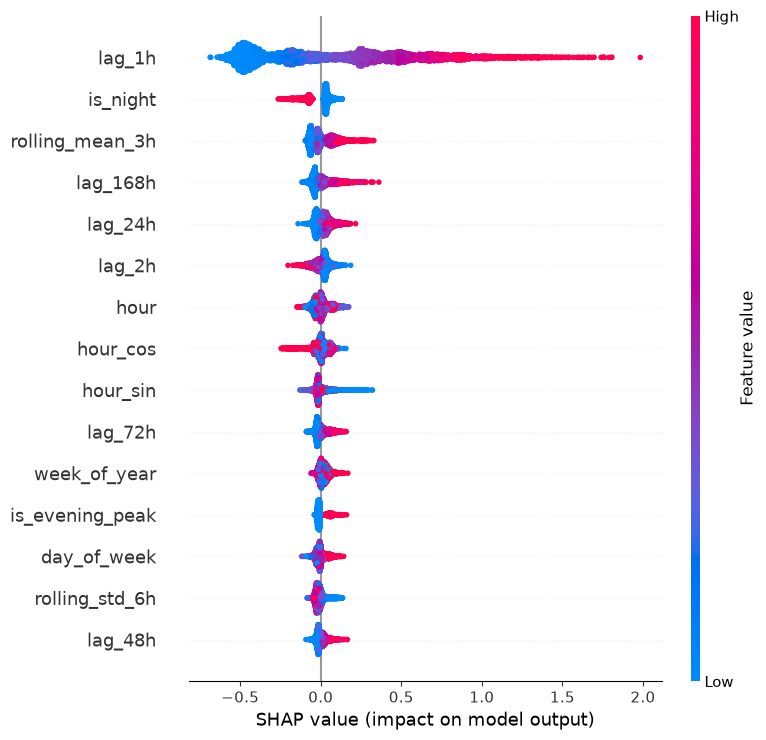

In [282]:
import matplotlib.pyplot as plt
import shap

shap.summary_plot(
    shap_values,
    X_val,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

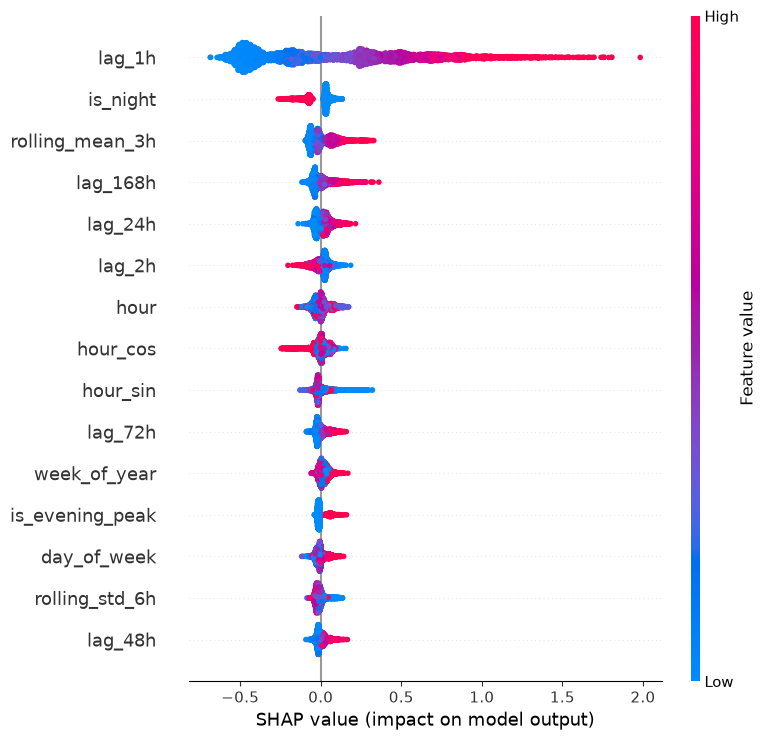

In [283]:
import matplotlib.pyplot as plt
import shap

plt.figure()

shap.summary_plot(
    shap_values,
    X_val,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

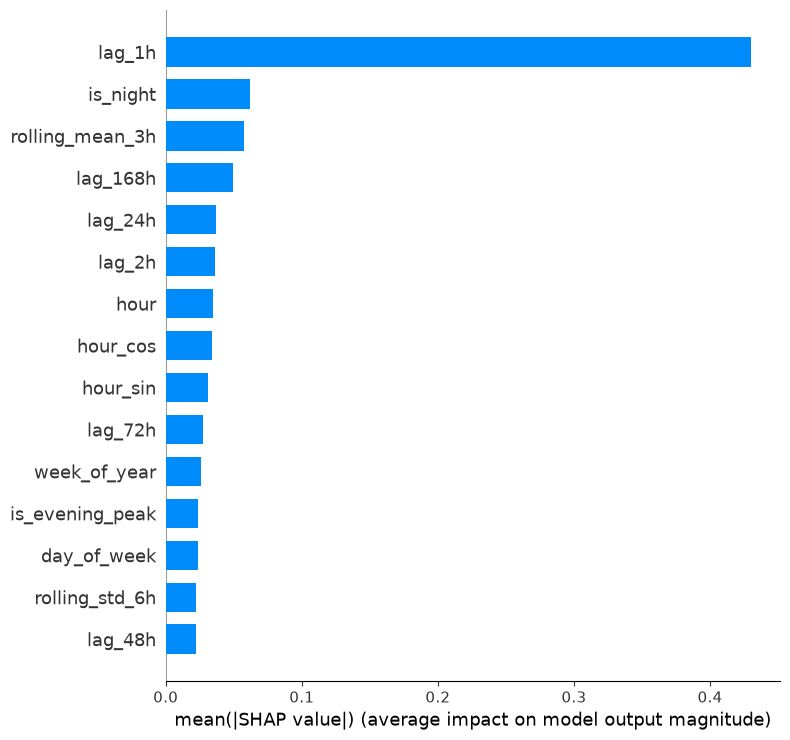

In [284]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

In [285]:
# Find the validation observation with the highest actual demand
high_demand_idx = y_val.idxmax()

print("Validation index:", high_demand_idx)
print("Actual demand:", y_val.loc[high_demand_idx], "kW")
print("Predicted demand:", best_xgb_model.predict(
    X_val.loc[[high_demand_idx]]
)[0], "kW")

Validation index: 2010-01-23 18:00:00
Actual demand: 5.265533333333334 kW
Predicted demand: 2.0468445 kW


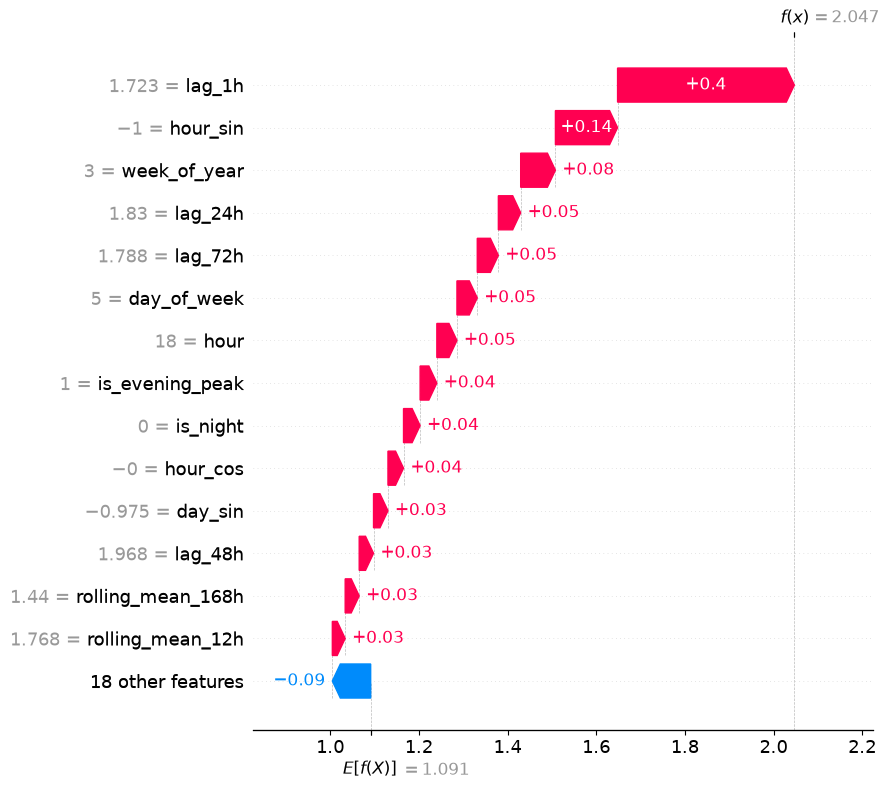

In [286]:
# Get the positional index inside X_val
position = X_val.index.get_loc(high_demand_idx)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_val.iloc[position],
        feature_names=X_val.columns
    ),
    max_display=15
)

Validation index: 2009-10-02 01:00:00
Actual demand: 0.19560000000000002 kW
Predicted demand: 0.3192308 kW


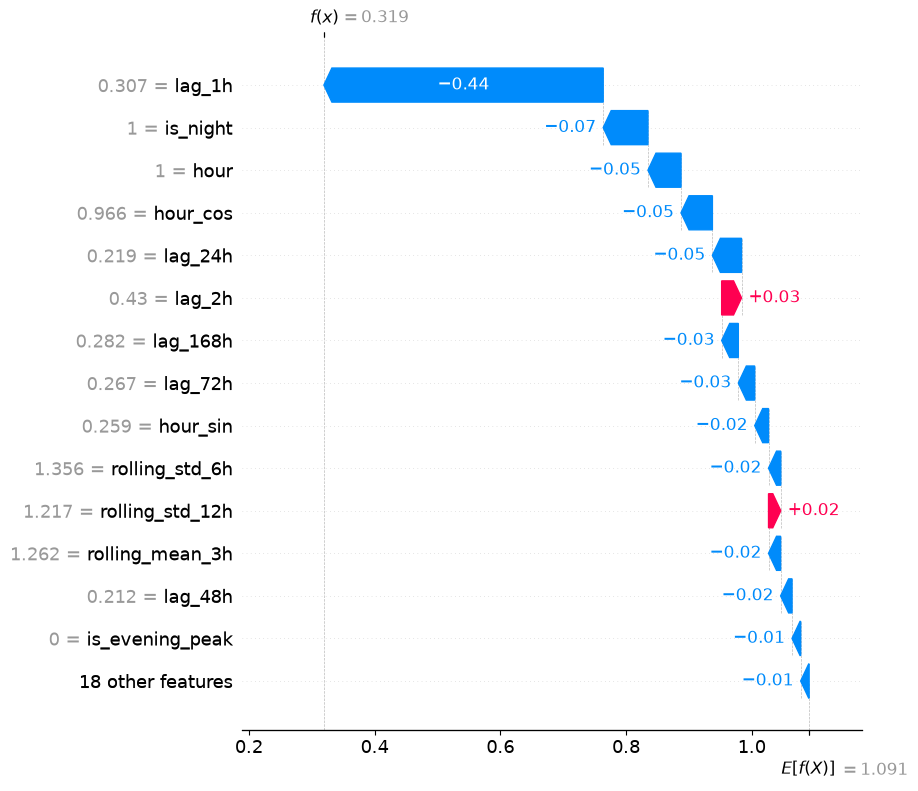

In [287]:
#  Explain a low-demand prediction too
low_demand_idx = y_val.idxmin()

print("Validation index:", low_demand_idx)
print("Actual demand:", y_val.loc[low_demand_idx], "kW")
print("Predicted demand:", best_xgb_model.predict(
    X_val.loc[[low_demand_idx]]
)[0], "kW")

position = X_val.index.get_loc(low_demand_idx)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_val.iloc[position],
        feature_names=X_val.columns
    ),
    max_display=15
)

In [288]:
print("Validation target maximum:", y_val.max())
print("Validation target minimum:", y_val.min())

print("\nTop 10 actual demands:")
print(y_val.nlargest(10))

print("\nBottom 10 actual demands:")
print(y_val.nsmallest(10))

Validation target maximum: 5.265533333333334
Validation target minimum: 0.19560000000000002

Top 10 actual demands:
timestamp
2010-01-23 18:00:00    5.265533
2010-01-30 18:00:00    5.142167
2009-11-22 20:00:00    5.115167
2010-02-21 11:00:00    5.090800
2009-11-03 20:00:00    4.830833
2009-11-21 17:00:00    4.768633
2009-12-24 19:00:00    4.675233
2009-12-24 17:00:00    4.670967
2009-10-17 16:00:00    4.663167
2010-02-21 14:00:00    4.638200
Name: demand_kw, dtype: float64

Bottom 10 actual demands:
timestamp
2009-10-02 01:00:00    0.195600
2009-09-28 15:00:00    0.203933
2009-09-18 14:00:00    0.204233
2009-10-04 05:00:00    0.205800
2009-10-01 11:00:00    0.206700
2009-09-27 04:00:00    0.207200
2009-09-30 01:00:00    0.211767
2009-09-10 02:00:00    0.213900
2009-10-01 01:00:00    0.219300
2009-10-02 04:00:00    0.226867
Name: demand_kw, dtype: float64


In [289]:
high_demand_idx = y_val.nlargest(1).index[0]

high_position = X_val.index.get_loc(high_demand_idx)

high_pred = best_xgb_model.predict(
    X_val.loc[[high_demand_idx]]
)[0]

print("High-demand index:", high_demand_idx)
print("Actual demand:", y_val.loc[high_demand_idx], "kW")
print("Predicted demand:", high_pred, "kW")

High-demand index: 2010-01-23 18:00:00
Actual demand: 5.265533333333334 kW
Predicted demand: 2.0468445 kW


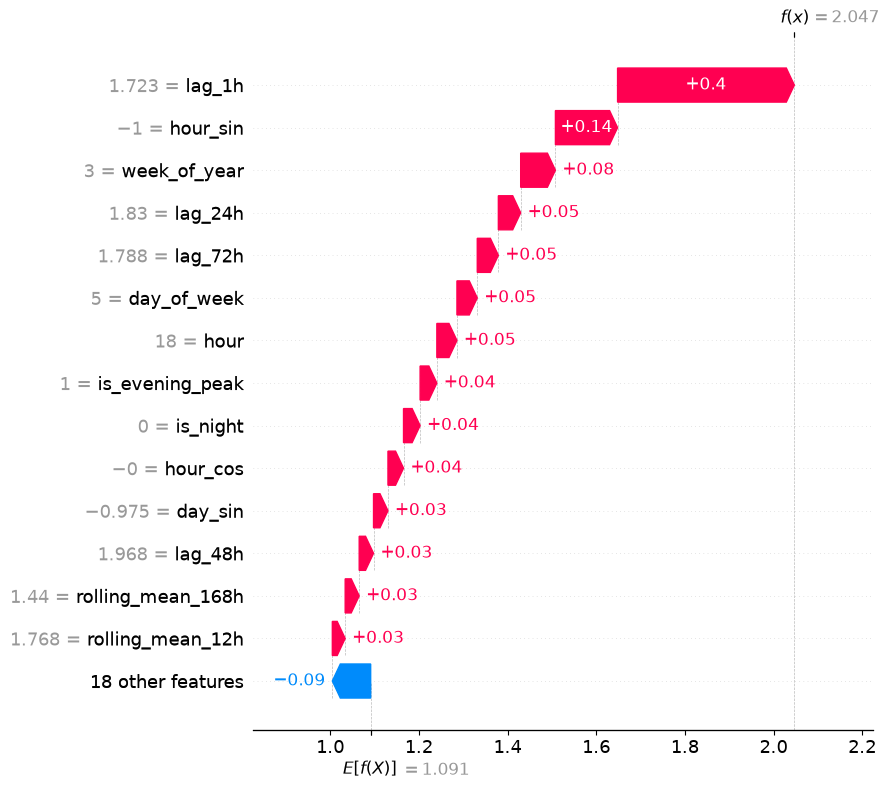

In [290]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_position],
        base_values=explainer.expected_value,
        data=X_val.iloc[high_position],
        feature_names=X_val.columns
    ),
    max_display=15
)

In [291]:
# Step 1 — Generate the high-demand SHAP explanation

high_demand_idx = y_val.nlargest(1).index[0]

high_position = X_val.index.get_loc(high_demand_idx)

high_pred = best_xgb_model.predict(
    X_val.loc[[high_demand_idx]]
)[0]

print("Timestamp:", high_demand_idx)
print("Actual demand:", y_val.loc[high_demand_idx], "kW")
print("Predicted demand:", high_pred, "kW")
print("Prediction error:", high_pred - y_val.loc[high_demand_idx], "kW")

Timestamp: 2010-01-23 18:00:00
Actual demand: 5.265533333333334 kW
Predicted demand: 2.0468445 kW
Prediction error: -3.218688850911459 kW


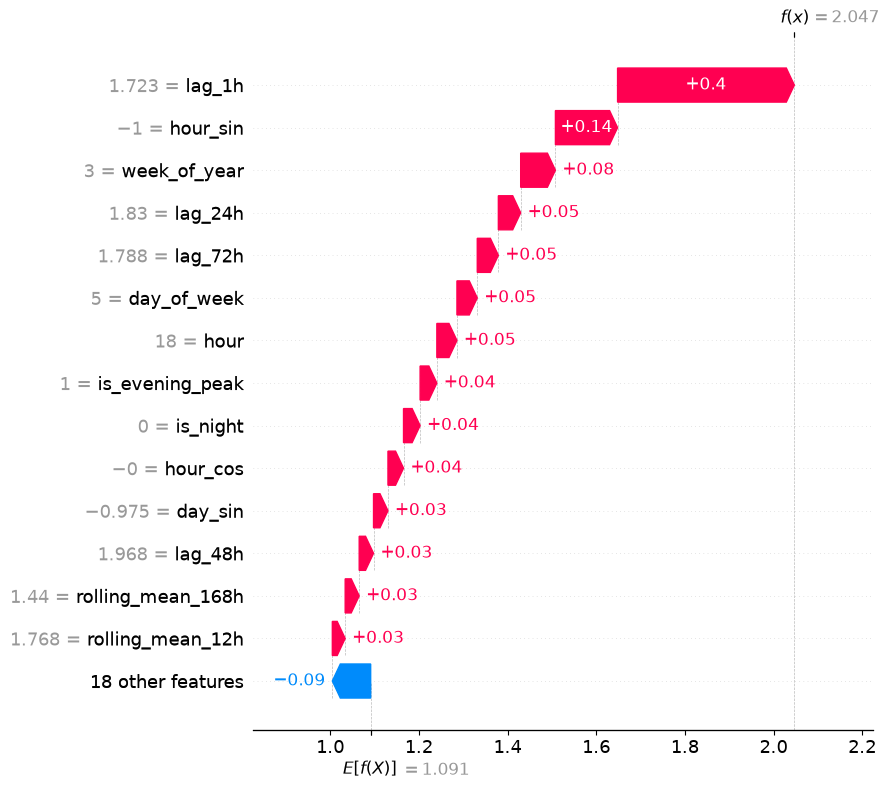

In [292]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_position],
        base_values=explainer.expected_value,
        data=X_val.iloc[high_position],
        feature_names=X_val.columns
    ),
    max_display=15
)

In [293]:
high_shap = pd.DataFrame({
    "feature": X_val.columns,
    "feature_value": X_val.iloc[high_position].values,
    "shap_value": shap_values[high_position]
})

high_shap["abs_shap"] = high_shap["shap_value"].abs()

high_shap = high_shap.sort_values(
    "abs_shap",
    ascending=False
)

print(high_shap.head(15).to_string(index=False))

          feature  feature_value  shap_value  abs_shap
           lag_1h   1.723100e+00    0.398718  0.398718
         hour_sin  -1.000000e+00    0.140214  0.140214
     week_of_year   3.000000e+00    0.078338  0.078338
          lag_24h   1.830267e+00    0.050367  0.050367
          lag_72h   1.787567e+00    0.047568  0.047568
      day_of_week   5.000000e+00    0.045837  0.045837
             hour   1.800000e+01    0.045347  0.045347
  is_evening_peak   1.000000e+00    0.037762  0.037762
         is_night   0.000000e+00    0.037402  0.037402
         hour_cos  -1.836970e-16    0.035095  0.035095
          day_sin  -9.749279e-01    0.032576  0.032576
          lag_48h   1.967533e+00    0.032326  0.032326
rolling_mean_168h   1.439829e+00    0.031625  0.031625
 rolling_mean_12h   1.768077e+00    0.028976  0.028976
 rolling_mean_48h   1.427951e+00   -0.024088  0.024088


In [294]:
from sklearn.ensemble import IsolationForest

print("Isolation Forest imported successfully.")

Isolation Forest imported successfully.


In [296]:
# Find dataframe variables currently available in the notebook

import pandas as pd

dataframes = {}

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        dataframes[name] = obj.shape

print("Available DataFrames:")
for name, shape in dataframes.items():
    print(f"{name}: {shape}")

Available DataFrames:
df: (2075259, 13)
missing_report: (10, 2)
gap_report: (2075259, 2)
missing_blocks: (71, 6)
df_processed: (2075259, 12)
largest_gap: (7226, 14)
missing_after_conversion: (7, 2)
measurement_missing_blocks: (71, 3)
df_check: (2075259, 12)
df_raw: (2075259, 9)
df_hourly_source: (2075259, 12)
hourly_df: (34589, 1)
feature_df: (34589, 33)
model_df: (32656, 33)
train_df: (22859, 33)
val_df: (4898, 33)
test_df: (4899, 33)
X_train: (22859, 32)
X_val: (4898, 32)
X_test: (4899, 32)
comparison: (2, 6)
baseline_results: (3, 6)
linear_comparison: (2, 6)
linear_predictions: (4898, 4)
_195: (5, 4)
model_comparison: (4, 6)
peak_comparison: (225, 2)
feature_importance: (32, 2)
top_features: (15, 2)
tuning_results_df: (6, 6)
final_xgb_comparison: (4, 6)
lightgbm_comparison: (5, 6)
lgbm_tuning_results_df: (6, 6)
threshold_df: (10, 4)
X_train_peak: (1143, 32)
X_val_peak: (225, 32)
threshold_df_v2: (10, 4)
high_shap: (32, 4)


In [297]:
print("\nAvailable Series:")
for name, obj in globals().items():
    if isinstance(obj, pd.Series):
        print(f"{name}: {obj.shape}")


Available Series:
missing_count: (10,)
missing_percentage: (10,)
time_diff: (2075259,)
gap_distribution: (4,)
missing_by_category: (4,)
missing_by_category_percentage: (4,)
missing_block_sizes: (71,)
short_gap_mask: (2075259,)
interpolated_sub3: (2075259,)
missing_pattern: (2,)
all_measurements_missing: (2075259,)
partial_missing: (2075259,)
_70: (2075259,)
feature_missing: (33,)
time_diffs: (32656,)
y_train: (22859,)
y_val: (4898,)
y_test: (4899,)
baseline_1h: (4899,)
baseline_24h: (4899,)
baseline_168h: (4899,)
best_baseline: (6,)
peak_mask: (4898,)
normal_mask: (4898,)
test_peak_mask: (4899,)
y_train_peak: (22859,)
y_val_peak: (4898,)
train_peak_mask: (22859,)
y_train_peak_reg: (1143,)
val_peak_mask: (4898,)
y_val_peak_reg: (225,)
actual_peak_mask: (4898,)


In [298]:
anomaly_data = feature_df.copy()

print("Anomaly dataset shape:", anomaly_data.shape)

print("\nColumns:")
print(anomaly_data.columns.tolist())

print("\nMissing values:")
print(anomaly_data.isna().sum().sort_values(ascending=False).head(10))

Anomaly dataset shape: (34589, 33)

Columns:
['demand_kw', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_night', 'is_evening_peak', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_72h', 'lag_168h', 'rolling_mean_3h', 'rolling_std_3h', 'rolling_mean_6h', 'rolling_std_6h', 'rolling_mean_12h', 'rolling_std_12h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_48h', 'rolling_std_48h', 'rolling_mean_168h', 'rolling_std_168h']

Missing values:
rolling_mean_168h    1925
rolling_std_168h     1925
rolling_mean_48h      845
rolling_std_48h       845
rolling_mean_24h      629
rolling_std_24h       629
lag_168h              589
rolling_std_12h       521
rolling_mean_12h      521
lag_72h               493
dtype: int64


In [299]:
anomaly_features = [
    "demand_kw",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_night",
    "is_evening_peak",
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_mean_24h",
    "rolling_std_24h"
]

X_anomaly = anomaly_data[anomaly_features].copy()

print("Anomaly feature matrix:", X_anomaly.shape)

print("\nMissing values:")
print(X_anomaly.isna().sum())

Anomaly feature matrix: (34589, 12)

Missing values:
demand_kw           421
hour                  0
day_of_week           0
is_weekend            0
is_night              0
is_evening_peak       0
lag_1h              422
lag_24h             445
lag_168h            589
rolling_mean_3h     440
rolling_mean_24h    629
rolling_std_24h     629
dtype: int64


In [300]:
# Keep rows where all anomaly features are available
anomaly_clean = anomaly_data[anomaly_features].dropna().copy()

# Preserve timestamp from the original DataFrame index
anomaly_clean["timestamp"] = anomaly_clean.index

print("Original anomaly rows:", len(anomaly_data))
print("Clean anomaly rows:", len(anomaly_clean))
print("Rows removed:", len(anomaly_data) - len(anomaly_clean))

print("\nMissing values after cleaning:")
print(anomaly_clean[anomaly_features].isna().sum().sum())

print("\nTimestamp range:")
print(anomaly_clean["timestamp"].min(), "to", anomaly_clean["timestamp"].max())

Original anomaly rows: 34589
Clean anomaly rows: 33387
Rows removed: 1202

Missing values after cleaning:
0

Timestamp range:
2006-12-23 17:00:00 to 2010-11-26 21:00:00


In [301]:
from sklearn.ensemble import IsolationForest

X_anomaly_clean = anomaly_clean[anomaly_features].copy()

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_anomaly_clean)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [302]:
# Generate anomaly predictions
anomaly_clean["anomaly_prediction"] = isolation_forest.predict(
    X_anomaly_clean
)

# Generate anomaly scores
anomaly_clean["anomaly_score"] = isolation_forest.decision_function(
    X_anomaly_clean
)

# -1 = anomaly, 1 = normal
anomaly_clean["is_anomaly"] = (
    anomaly_clean["anomaly_prediction"] == -1
)

print("Normal observations:",
      (~anomaly_clean["is_anomaly"]).sum())

print("Anomalous observations:",
      anomaly_clean["is_anomaly"].sum())

print(
    "Anomaly percentage:",
    round(anomaly_clean["is_anomaly"].mean() * 100, 2),
    "%"
)

Normal observations: 31717
Anomalous observations: 1670
Anomaly percentage: 5.0 %


In [303]:
top_anomalies = anomaly_clean[
    anomaly_clean["is_anomaly"]
].sort_values(
    "anomaly_score"
).head(20)

print(
    top_anomalies[
        [
            "timestamp",
            "demand_kw",
            "hour",
            "day_of_week",
            "is_weekend",
            "lag_1h",
            "lag_24h",
            "rolling_mean_24h",
            "anomaly_score"
        ]
    ].to_string(index=False)
)

          timestamp  demand_kw  hour  day_of_week  is_weekend   lag_1h  lag_24h  rolling_mean_24h  anomaly_score
2009-01-18 22:00:00   2.693833    22            6           1 4.860700 2.403400          2.202411      -0.115846
2007-12-23 20:00:00   3.241233    20            6           1 6.488000 4.925500          1.902886      -0.114224
2007-02-04 01:00:00   4.159333     1            6           1 5.073333 3.490833          2.855028      -0.113029
2008-11-23 21:00:00   3.775733    21            6           1 6.310567 3.893167          2.263135      -0.112664
2007-03-05 20:00:00   4.205433    20            0           0 5.644900 4.096200          1.826957      -0.112633
2007-02-10 22:00:00   4.690500    22            5           1 2.560467 3.835767          1.823321      -0.111948
2008-11-30 22:00:00   2.485600    22            6           1 4.156633 3.005733          1.759410      -0.110120
2006-12-24 00:00:00   4.028000     0            6           1 5.562467 1.698233          3.31485

In [306]:
high_demand_anomalies = anomaly_clean[
    anomaly_clean["is_anomaly"]
].sort_values(
    "demand_kw",
    ascending=False
).head(20)

print(
    high_demand_anomalies[
        [
            "timestamp",
            "demand_kw",
            "hour",
            "day_of_week",
            "is_weekend",
            "lag_1h",
            "lag_24h",
            "rolling_mean_24h",
            "anomaly_score"
        ]
    ].to_string(index=False)
)

          timestamp  demand_kw  hour  day_of_week  is_weekend   lag_1h  lag_24h  rolling_mean_24h  anomaly_score
2008-11-23 18:00:00   6.560533    18            6           1 4.205967 1.104333          1.768800      -0.069310
2009-01-16 20:00:00   6.519633    20            4           0 4.958200 3.364000          1.601418      -0.070066
2008-02-02 19:00:00   6.496033    19            5           1 2.786167 1.096133          1.333229      -0.038235
2007-12-23 19:00:00   6.488000    19            6           1 3.126667 2.785933          1.748633      -0.043283
2007-02-22 21:00:00   6.363867    21            3           0 3.460833 2.113133          2.120635      -0.042831
2007-12-28 17:00:00   6.333667    17            4           0 5.137800 2.498700          1.990439      -0.078651
2008-11-23 20:00:00   6.310567    20            6           1 3.742833 2.133267          2.089081      -0.100468
2007-01-21 20:00:00   6.076567    20            6           1 5.330433 3.712933          2.09498

In [307]:
anomaly_clean["change_from_previous_hour"] = (
    anomaly_clean["demand_kw"] -
    anomaly_clean["lag_1h"]
)

anomaly_clean["absolute_change"] = (
    anomaly_clean["change_from_previous_hour"].abs()
)

In [308]:
sudden_change_anomalies = anomaly_clean[
    anomaly_clean["is_anomaly"]
].sort_values(
    "absolute_change",
    ascending=False
).head(20)

print(
    sudden_change_anomalies[
        [
            "timestamp",
            "demand_kw",
            "lag_1h",
            "change_from_previous_hour",
            "hour",
            "is_weekend",
            "anomaly_score"
        ]
    ].to_string(index=False)
)

          timestamp  demand_kw   lag_1h  change_from_previous_hour  hour  is_weekend  anomaly_score
2008-10-19 02:00:00   1.196033 5.759067                  -4.563033     2           1      -0.075602
2008-03-13 22:00:00   0.662867 5.014167                  -4.351300    22           0      -0.050911
2007-09-26 22:00:00   0.909667 4.821867                  -3.912200    22           0      -0.028678
2007-09-17 21:00:00   5.735767 1.974600                   3.761167    21           0      -0.022000
2008-02-02 19:00:00   6.496033 2.786167                   3.709867    19           1      -0.038235
2009-04-12 22:00:00   1.483967 5.133967                  -3.650000    22           1      -0.091411
2008-01-14 22:00:00   1.116500 4.745200                  -3.628700    22           0      -0.072203
2007-12-08 21:00:00   1.603567 5.212933                  -3.609367    21           1      -0.077049
2007-01-21 22:00:00   2.327733 5.910767                  -3.583033    22           1      -0.104446


In [309]:
# Create anomaly categories
# Define practical anomaly categories

HIGH_DEMAND_THRESHOLD = anomaly_clean["demand_kw"].quantile(0.95)
SUDDEN_CHANGE_THRESHOLD = anomaly_clean["absolute_change"].quantile(0.95)

anomaly_clean["anomaly_category"] = "Normal"

anomaly_mask = anomaly_clean["is_anomaly"]

# High consumption
high_demand_mask = (
    anomaly_mask &
    (anomaly_clean["demand_kw"] >= HIGH_DEMAND_THRESHOLD)
)

anomaly_clean.loc[
    high_demand_mask,
    "anomaly_category"
] = "High Consumption"

# Sudden change
sudden_change_mask = (
    anomaly_mask &
    (anomaly_clean["absolute_change"] >= SUDDEN_CHANGE_THRESHOLD)
)

anomaly_clean.loc[
    sudden_change_mask,
    "anomaly_category"
] = "Sudden Change"

# Both conditions
both_mask = (
    high_demand_mask &
    sudden_change_mask
)

anomaly_clean.loc[
    both_mask,
    "anomaly_category"
] = "High Consumption + Sudden Change"

print("High-demand threshold:",
      round(HIGH_DEMAND_THRESHOLD, 3), "kW")

print("Sudden-change threshold:",
      round(SUDDEN_CHANGE_THRESHOLD, 3), "kW")

print("\nAnomaly categories:")
print(
    anomaly_clean["anomaly_category"]
    .value_counts()
)

High-demand threshold: 2.855 kW
Sudden-change threshold: 1.492 kW

Anomaly categories:
anomaly_category
Normal                              32564
High Consumption                      480
Sudden Change                         213
High Consumption + Sudden Change      130
Name: count, dtype: int64


In [310]:
anomaly_results = anomaly_clean[
    [
        "timestamp",
        "demand_kw",
        "hour",
        "day_of_week",
        "is_weekend",
        "lag_1h",
        "lag_24h",
        "rolling_mean_24h",
        "change_from_previous_hour",
        "absolute_change",
        "anomaly_score",
        "is_anomaly",
        "anomaly_category"
    ]
].copy()

print("Final anomaly results:", anomaly_results.shape)

print("\nDetected potential anomalies:")
print(
    anomaly_results[
        anomaly_results["is_anomaly"]
    ].head(10).to_string(index=False)
)

Final anomaly results: (33387, 13)

Detected potential anomalies:
          timestamp  demand_kw  hour  day_of_week  is_weekend   lag_1h  lag_24h  rolling_mean_24h  change_from_previous_hour  absolute_change  anomaly_score  is_anomaly                 anomaly_category
2006-12-23 17:00:00   5.452533    17            5           1 4.349100 1.496800          2.934890                   1.103433         1.103433      -0.087771        True                 High Consumption
2006-12-23 18:00:00   3.879400    18            5           1 5.452533 2.686967          3.099713                  -1.573133         1.573133      -0.099258        True High Consumption + Sudden Change
2006-12-23 19:00:00   4.117833    19            5           1 3.879400 3.938167          3.149397                   0.238433         0.238433      -0.103317        True                 High Consumption
2006-12-23 20:00:00   4.181400    20            5           1 4.117833 3.536067          3.156883                   0.063567  

In [311]:
# Check the anomaly timeline
print("First anomaly timestamp:")
print(anomaly_results[anomaly_results["is_anomaly"]]["timestamp"].min())

print("\nFirst 20 timestamps in anomaly dataset:")
print(anomaly_results["timestamp"].head(20).to_string(index=False))

First anomaly timestamp:
2006-12-23 17:00:00

First 20 timestamps in anomaly dataset:
timestamp
2006-12-23 17:00:00
2006-12-23 18:00:00
2006-12-23 19:00:00
2006-12-23 20:00:00
2006-12-23 21:00:00
2006-12-23 22:00:00
2006-12-23 23:00:00
2006-12-24 00:00:00
2006-12-24 01:00:00
2006-12-24 02:00:00
2006-12-24 03:00:00
2006-12-24 04:00:00
2006-12-24 05:00:00
2006-12-24 06:00:00
2006-12-24 07:00:00
2006-12-24 08:00:00
2006-12-24 09:00:00
2006-12-24 10:00:00
2006-12-24 11:00:00
2006-12-24 12:00:00


In [312]:
print("\nAnomalies during first 7 days:")

first_week = anomaly_results[
    anomaly_results["timestamp"] <
    anomaly_results["timestamp"].min() + pd.Timedelta(days=7)
]

print(
    first_week["anomaly_category"]
    .value_counts()
)


Anomalies during first 7 days:
anomaly_category
Normal                              134
High Consumption                     23
High Consumption + Sudden Change      6
Sudden Change                         5
Name: count, dtype: int64


In [313]:
# Fix the anomaly categories

# Correct the category naming
anomaly_results.loc[
    anomaly_results["is_anomaly"] &
    (anomaly_results["anomaly_category"] == "Normal"),
    "anomaly_category"
] = "Other Detected Anomaly"

print(
    anomaly_results["anomaly_category"].value_counts()
)

anomaly_category
Normal                              31717
Other Detected Anomaly                847
High Consumption                      480
Sudden Change                         213
High Consumption + Sudden Change      130
Name: count, dtype: int64


In [314]:
# Correct the category naming

anomaly_results.loc[
    anomaly_results["is_anomaly"] &
    (anomaly_results["anomaly_category"] == "Normal"),
    "anomaly_category"
] = "Other Detected Anomaly"

print("Updated anomaly categories:")
print(
    anomaly_results["anomaly_category"].value_counts()
)

Updated anomaly categories:
anomaly_category
Normal                              31717
Other Detected Anomaly                847
High Consumption                      480
Sudden Change                         213
High Consumption + Sudden Change      130
Name: count, dtype: int64


In [315]:
# Validate category totals

category_counts = anomaly_results["anomaly_category"].value_counts()

print("\nTotal observations:", len(anomaly_results))
print("Potential anomalies:", anomaly_results["is_anomaly"].sum())

print("\nPotential anomaly percentage:",
      round(
          anomaly_results["is_anomaly"].mean() * 100,
          2
      ),
      "%")

print("\nCategory breakdown:")
print(category_counts)


Total observations: 33387
Potential anomalies: 1670

Potential anomaly percentage: 5.0 %

Category breakdown:
anomaly_category
Normal                              31717
Other Detected Anomaly                847
High Consumption                      480
Sudden Change                         213
High Consumption + Sudden Change      130
Name: count, dtype: int64


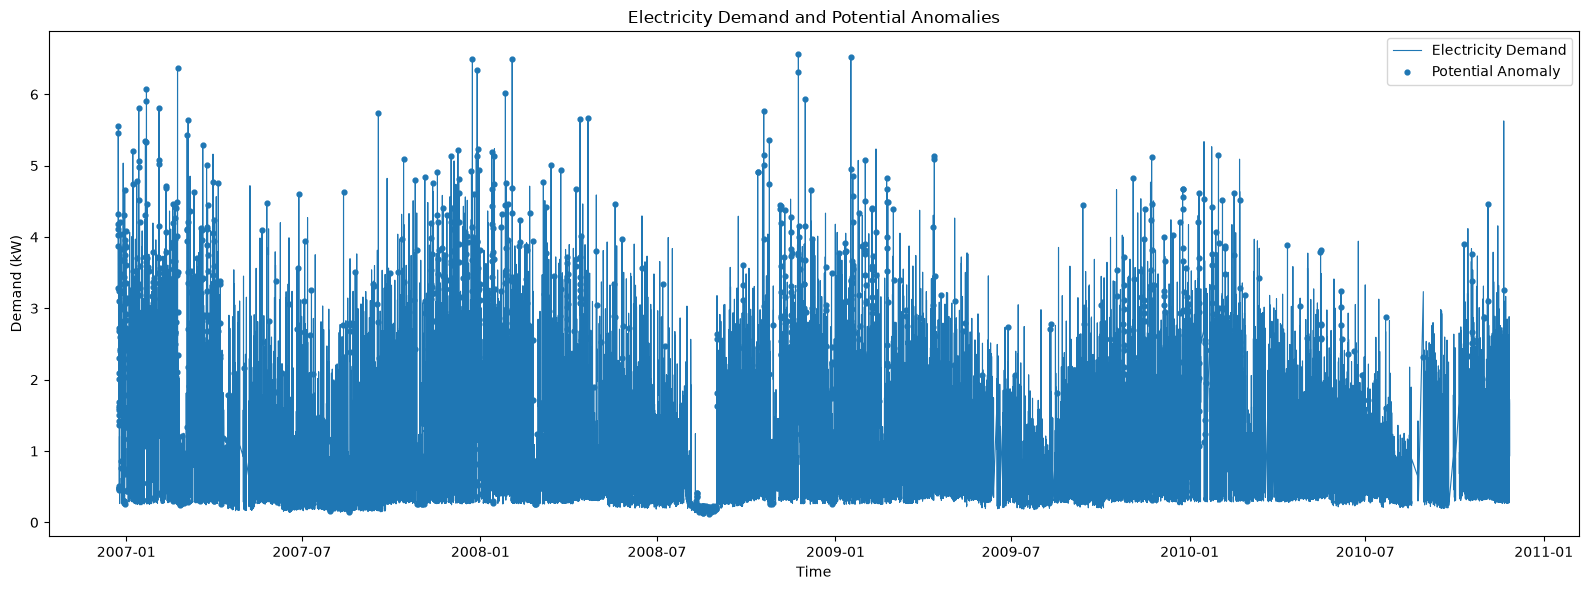

In [316]:
# Create the anomaly visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    anomaly_results["timestamp"],
    anomaly_results["demand_kw"],
    linewidth=0.8,
    label="Electricity Demand"
)

potential_anomalies = anomaly_results[
    anomaly_results["is_anomaly"]
]

plt.scatter(
    potential_anomalies["timestamp"],
    potential_anomalies["demand_kw"],
    s=12,
    label="Potential Anomaly"
)

plt.xlabel("Time")
plt.ylabel("Demand (kW)")
plt.title("Electricity Demand and Potential Anomalies")
plt.legend()
plt.tight_layout()
plt.show()

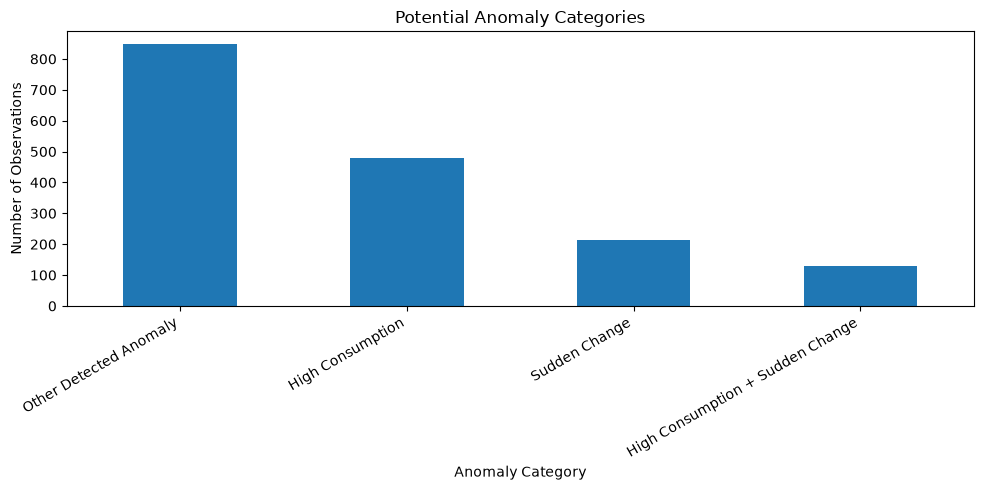

In [317]:
category_counts = (
    anomaly_results[
        anomaly_results["is_anomaly"]
    ]["anomaly_category"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

category_counts.plot(kind="bar")

plt.xlabel("Anomaly Category")
plt.ylabel("Number of Observations")
plt.title("Potential Anomaly Categories")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [318]:
top_anomalies = (
    anomaly_results[
        anomaly_results["is_anomaly"]
    ]
    .sort_values("anomaly_score")
    .head(20)
)

print(
    top_anomalies[
        [
            "timestamp",
            "demand_kw",
            "hour",
            "lag_1h",
            "lag_24h",
            "rolling_mean_24h",
            "change_from_previous_hour",
            "anomaly_score",
            "anomaly_category"
        ]
    ].to_string(index=False)
)

          timestamp  demand_kw  hour   lag_1h  lag_24h  rolling_mean_24h  change_from_previous_hour  anomaly_score                 anomaly_category
2009-01-18 22:00:00   2.693833    22 4.860700 2.403400          2.202411                  -2.166867      -0.115846                    Sudden Change
2007-12-23 20:00:00   3.241233    20 6.488000 4.925500          1.902886                  -3.246767      -0.114224 High Consumption + Sudden Change
2007-02-04 01:00:00   4.159333     1 5.073333 3.490833          2.855028                  -0.914000      -0.113029                 High Consumption
2008-11-23 21:00:00   3.775733    21 6.310567 3.893167          2.263135                  -2.534833      -0.112664 High Consumption + Sudden Change
2007-03-05 20:00:00   4.205433    20 5.644900 4.096200          1.826957                  -1.439467      -0.112633                 High Consumption
2007-02-10 22:00:00   4.690500    22 2.560467 3.835767          1.823321                   2.130033      -0.1119

In [319]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

anomaly_model_path = models_dir / "isolation_forest_anomaly_detector.joblib"

joblib.dump(
    isolation_forest,
    anomaly_model_path
)

print("Model saved to:")
print(anomaly_model_path)

Model saved to:
..\models\isolation_forest_anomaly_detector.joblib


In [320]:
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

anomaly_results_path = results_dir / "anomaly_detection_results.csv"

anomaly_results.to_csv(
    anomaly_results_path,
    index=False
)

print("Results saved to:")
print(anomaly_results_path)

Results saved to:
..\results\anomaly_detection_results.csv


In [322]:
import json

anomaly_metadata = {
    "model": "Isolation Forest",
    "task": "Electricity consumption anomaly detection",
    "contamination": 0.05,
    "n_estimators": 300,
    "random_state": 42,
    "anomaly_count": int(anomaly_results["is_anomaly"].sum()),
    "total_observations": int(len(anomaly_results)),
    "anomaly_percentage": round(
        anomaly_results["is_anomaly"].mean() * 100,
        2
    ),
    "high_demand_threshold_kw": round(
        HIGH_DEMAND_THRESHOLD,
        3
    ),
    "sudden_change_threshold_kw": round(
        SUDDEN_CHANGE_THRESHOLD,
        3
    ),
    "features": anomaly_features
}

metadata_path = results_dir / "anomaly_detection_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(anomaly_metadata, f, indent=4)

print("Metadata saved to:")
print(metadata_path)

Metadata saved to:
..\results\anomaly_detection_metadata.json


In [323]:
# Convert demand into energy consumption
# Create hourly energy consumption

cost_df = anomaly_results.copy()

cost_df["energy_kwh"] = cost_df["demand_kw"] * 1.0

print(
    cost_df[
        ["timestamp", "demand_kw", "energy_kwh"]
    ].head(10)
)

                              timestamp  demand_kw  energy_kwh
timestamp                                                     
2006-12-23 17:00:00 2006-12-23 17:00:00   5.452533    5.452533
2006-12-23 18:00:00 2006-12-23 18:00:00   3.879400    3.879400
2006-12-23 19:00:00 2006-12-23 19:00:00   4.117833    4.117833
2006-12-23 20:00:00 2006-12-23 20:00:00   4.181400    4.181400
2006-12-23 21:00:00 2006-12-23 21:00:00   3.288433    3.288433
2006-12-23 22:00:00 2006-12-23 22:00:00   4.327933    4.327933
2006-12-23 23:00:00 2006-12-23 23:00:00   5.562467    5.562467
2006-12-24 00:00:00 2006-12-24 00:00:00   4.028000    4.028000
2006-12-24 01:00:00 2006-12-24 01:00:00   3.275700    3.275700
2006-12-24 02:00:00 2006-12-24 02:00:00   2.303033    2.303033


In [324]:
# Daily energy consumption

cost_df["date"] = cost_df["timestamp"].dt.date

daily_consumption = (
    cost_df
    .groupby("date")["energy_kwh"]
    .sum()
    .reset_index()
)

daily_consumption.columns = [
    "date",
    "daily_energy_kwh"
]

print("Daily consumption shape:")
print(daily_consumption.shape)

print("\nFirst 10 days:")
print(
    daily_consumption.head(10).to_string(index=False)
)

print("\nAverage daily consumption:",
      round(
          daily_consumption["daily_energy_kwh"].mean(),
          2
      ),
      "kWh")

Daily consumption shape:
(1411, 2)

First 10 days:
      date  daily_energy_kwh
2006-12-23         30.810000
2006-12-24         42.500200
2006-12-25         45.718667
2006-12-26         65.568500
2006-12-27         25.479333
2006-12-28         34.543967
2006-12-29         52.906533
2006-12-30         46.643860
2006-12-31         58.236600
2007-01-01         45.816733

Average daily consumption: 25.77 kWh


In [325]:
# Create monthly period

cost_df["month"] = (
    cost_df["timestamp"]
    .dt.to_period("M")
)

monthly_consumption = (
    cost_df
    .groupby("month")["energy_kwh"]
    .sum()
    .reset_index()
)

monthly_consumption.columns = [
    "month",
    "monthly_energy_kwh"
]

print("Monthly consumption shape:")
print(monthly_consumption.shape)

print("\nFirst 12 months:")
print(
    monthly_consumption.head(12).to_string(index=False)
)

Monthly consumption shape:
(48, 2)

First 12 months:
  month  monthly_energy_kwh
2006-12          402.407660
2007-01         1150.299719
2007-02          941.598618
2007-03          981.042376
2007-04          580.047862
2007-05          644.245933
2007-06          595.848921
2007-07          479.093219
2007-08          568.665122
2007-09          697.954768
2007-10          821.346041
2007-11          932.030674


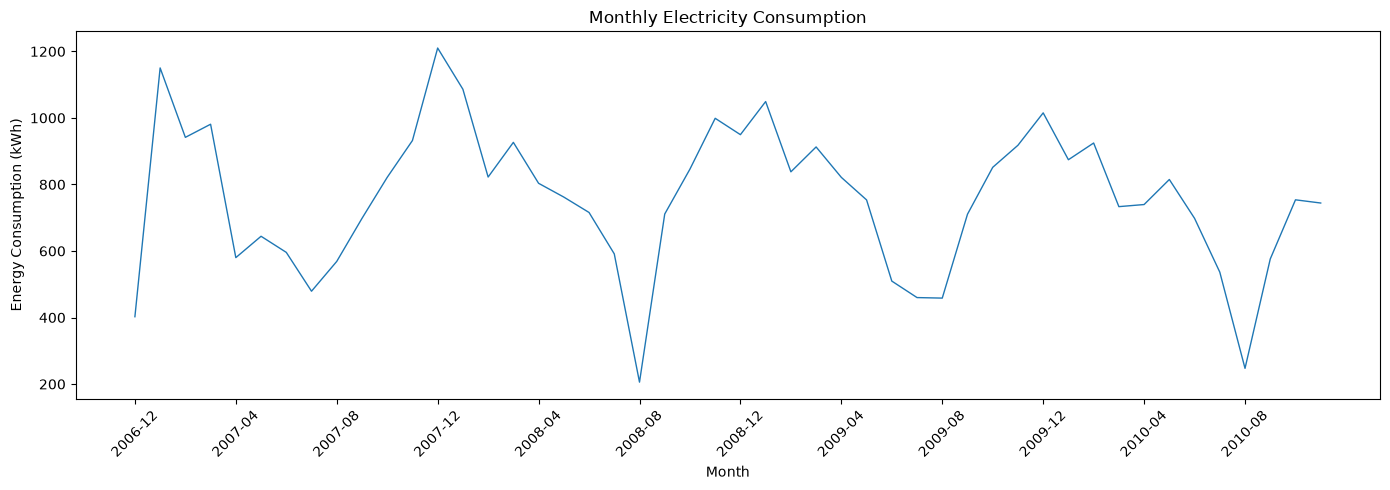

In [326]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_consumption["month"].astype(str),
    monthly_consumption["monthly_energy_kwh"],
    linewidth=1
)

plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Monthly Electricity Consumption")

plt.xticks(
    range(
        0,
        len(monthly_consumption),
        max(1, len(monthly_consumption) // 12)
    ),
    rotation=45
)

plt.tight_layout()
plt.show()

In [327]:
def calculate_electricity_cost(
    energy_kwh,
    fixed_charge=0,
    tariff_rate=0
):
    """
    Calculate estimated electricity cost.

    Parameters
    ----------
    energy_kwh : float
        Electricity consumption in kWh.
    fixed_charge : float
        Fixed charge for the billing period.
    tariff_rate : float
        Cost per kWh.

    Returns
    -------
    float
        Estimated electricity cost.
    """

    variable_cost = energy_kwh * tariff_rate

    total_cost = variable_cost + fixed_charge

    return total_cost

In [328]:
test_energy = 100

test_cost = calculate_electricity_cost(
    energy_kwh=test_energy,
    fixed_charge=100,
    tariff_rate=30
)

print("Test energy:", test_energy, "kWh")
print("Test cost:", test_cost)

Test energy: 100 kWh
Test cost: 3100


In [329]:
def calculate_tiered_cost(
    energy_kwh,
    tiers,
    fixed_charge=0
):
    """
    Calculate electricity cost using tiered consumption rates.

    tiers format:
    [
        (upper_limit, rate),
        (upper_limit, rate),
        ...
        (None, rate)
    ]

    Example:
    [
        (60, 20),
        (90, 30),
        (None, 40)
    ]
    """

    remaining_energy = energy_kwh
    previous_limit = 0
    variable_cost = 0

    for upper_limit, rate in tiers:

        if remaining_energy <= 0:
            break

        if upper_limit is None:
            tier_energy = remaining_energy
        else:
            tier_capacity = upper_limit - previous_limit
            tier_energy = min(
                remaining_energy,
                tier_capacity
            )

        variable_cost += tier_energy * rate
        remaining_energy -= tier_energy

        if upper_limit is not None:
            previous_limit = upper_limit

    return variable_cost + fixed_charge

In [330]:
test_tiers = [
    (60, 20),
    (90, 30),
    (None, 40)
]

test_energy = 100

test_cost = calculate_tiered_cost(
    energy_kwh=test_energy,
    tiers=test_tiers,
    fixed_charge=100
)

print("Test energy:", test_energy, "kWh")
print("Test cost:", test_cost)

Test energy: 100 kWh
Test cost: 2600


In [331]:
def calculate_tiered_cost(
    energy_kwh,
    tiers,
    fixed_charge=0
):
    """
    Calculate electricity cost using tiered consumption rates.

    tiers format:
    [
        (upper_limit, rate),
        (upper_limit, rate),
        ...
        (None, rate)
    ]

    Example:
    [
        (60, 20),
        (90, 30),
        (None, 40)
    ]
    """

    remaining_energy = energy_kwh
    previous_limit = 0
    variable_cost = 0

    for upper_limit, rate in tiers:

        if remaining_energy <= 0:
            break

        if upper_limit is None:
            tier_energy = remaining_energy
        else:
            tier_capacity = upper_limit - previous_limit
            tier_energy = min(
                remaining_energy,
                tier_capacity
            )

        variable_cost += tier_energy * rate
        remaining_energy -= tier_energy

        if upper_limit is not None:
            previous_limit = upper_limit

    return variable_cost + fixed_charge

In [332]:
test_tiers = [
    (60, 20),
    (90, 30),
    (None, 40)
]

test_energy = 100

test_cost = calculate_tiered_cost(
    energy_kwh=test_energy,
    tiers=test_tiers,
    fixed_charge=100
)

print("Test energy:", test_energy, "kWh")
print("Test cost:", test_cost)

Test energy: 100 kWh
Test cost: 2600


In [333]:
# Temporary test tariff
test_tiers = [
    (60, 20),
    (90, 30),
    (None, 40)
]

test_fixed_charge = 100


# Calculate estimated monthly cost
monthly_consumption["estimated_cost"] = (
    monthly_consumption["monthly_energy_kwh"]
    .apply(
        lambda x: calculate_tiered_cost(
            energy_kwh=x,
            tiers=test_tiers,
            fixed_charge=test_fixed_charge
        )
    )
)

print(
    monthly_consumption.head(12).to_string(index=False)
)

  month  monthly_energy_kwh  estimated_cost
2006-12          402.407660    14696.306391
2007-01         1150.299719    44611.988746
2007-02          941.598618    36263.944736
2007-03          981.042376    37841.695028
2007-04          580.047862    21801.914476
2007-05          644.245933    24369.837333
2007-06          595.848921    22433.956829
2007-07          479.093219    17763.728780
2007-08          568.665122    21346.604862
2007-09          697.954768    26518.190713
2007-10          821.346041    31453.841655
2007-11          932.030674    35881.226960


In [334]:
print("\nCost statistics:")

print(
    monthly_consumption["estimated_cost"]
    .describe()
)


Cost statistics:
count       48.000000
mean     28903.598466
std       8706.756679
min       6830.350034
25%      22388.794496
50%      28917.851447
75%      35381.044729
max      47003.408249
Name: estimated_cost, dtype: float64


In [335]:
print("\nHighest estimated-cost months:")

print(
    monthly_consumption
    .sort_values(
        "estimated_cost",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)


Highest estimated-cost months:
  month  monthly_energy_kwh  estimated_cost
2007-12         1210.085206    47003.408249
2007-01         1150.299719    44611.988746
2008-01         1086.219594    42048.783751
2009-01         1049.221628    40568.865130
2009-12         1015.165614    39206.624552
2008-11          998.868232    38554.729264
2007-03          981.042376    37841.695028
2008-12          949.670599    36586.823972
2007-02          941.598618    36263.944736
2007-11          932.030674    35881.226960


In [336]:
# Electricity tariff configuration
# Temporary values for development/testing only

TARIFF_CONFIG = {
    "name": "Development Test Tariff",
    "currency": "LKR",
    "tiers": [
        {
            "upper_limit": 60,
            "rate": 20
        },
        {
            "upper_limit": 90,
            "rate": 30
        },
        {
            "upper_limit": None,
            "rate": 40
        }
    ],
    "fixed_charge": 100
}

print(TARIFF_CONFIG)

{'name': 'Development Test Tariff', 'currency': 'LKR', 'tiers': [{'upper_limit': 60, 'rate': 20}, {'upper_limit': 90, 'rate': 30}, {'upper_limit': None, 'rate': 40}], 'fixed_charge': 100}


In [337]:
def calculate_configured_cost(
    energy_kwh,
    tariff_config
):
    return calculate_tiered_cost(
        energy_kwh=energy_kwh,
        tiers=[
            (
                tier["upper_limit"],
                tier["rate"]
            )
            for tier in tariff_config["tiers"]
        ],
        fixed_charge=tariff_config["fixed_charge"]
    )

In [338]:
test_energy = 100

cost = calculate_configured_cost(
    test_energy,
    TARIFF_CONFIG
)

print(
    f"{test_energy} kWh estimated cost: "
    f"LKR {cost:,.2f}"
)

100 kWh estimated cost: LKR 2,600.00


In [339]:
official_bill_examples = {
    30: 230,
    60: 630,
    90: 1840,
    120: 3280,
    150: 5100,
    180: 6420,
    210: 9570,
    240: 12120,
    270: 14670,
    300: 17220
}

print("Official tariff validation examples:")

for units, bill in official_bill_examples.items():
    print(
        f"{units:>3} kWh -> LKR {bill:,.2f}"
    )

Official tariff validation examples:
 30 kWh -> LKR 230.00
 60 kWh -> LKR 630.00
 90 kWh -> LKR 1,840.00
120 kWh -> LKR 3,280.00
150 kWh -> LKR 5,100.00
180 kWh -> LKR 6,420.00
210 kWh -> LKR 9,570.00
240 kWh -> LKR 12,120.00
270 kWh -> LKR 14,670.00
300 kWh -> LKR 17,220.00


In [340]:
tariff_config_2026 = {
    "country": "Sri Lanka",
    "customer_category": "Domestic",
    "tariff_type": "Block Tariff",
    "effective_from": "2026-05-11",
    "currency": "LKR",
    "source": "PUCSL",
    "source_description": "Decision on Electricity Tariffs – 2026 May"
}

print(tariff_config_2026)

{'country': 'Sri Lanka', 'customer_category': 'Domestic', 'tariff_type': 'Block Tariff', 'effective_from': '2026-05-11', 'currency': 'LKR', 'source': 'PUCSL', 'source_description': 'Decision on Electricity Tariffs – 2026 May'}


In [341]:
# Sri Lankan domestic electricity bill calculator
# Based on the selected 2026 PUCSL tariff configuration

OFFICIAL_BILL_TABLE = {
    30: 230,
    60: 630,
    90: 1840,
    120: 3280,
    150: 5100,
    180: 6420,
    210: 9570,
    240: 12120,
    270: 14670,
    300: 17220
}


def calculate_sri_lanka_bill(energy_kwh):
    """
    Estimate electricity bill using the selected
    Sri Lankan domestic tariff reference values.
    """

    energy_kwh = float(energy_kwh)

    # Exact reference point
    if energy_kwh in OFFICIAL_BILL_TABLE:
        return OFFICIAL_BILL_TABLE[int(energy_kwh)]

    # For values between reference points,
    # temporarily use linear interpolation.
    sorted_points = sorted(OFFICIAL_BILL_TABLE.items())

    if energy_kwh <= sorted_points[0][0]:
        return sorted_points[0][1]

    for i in range(len(sorted_points) - 1):
        lower_kwh, lower_bill = sorted_points[i]
        upper_kwh, upper_bill = sorted_points[i + 1]

        if lower_kwh <= energy_kwh <= upper_kwh:

            ratio = (
                (energy_kwh - lower_kwh)
                / (upper_kwh - lower_kwh)
            )

            return lower_bill + (
                ratio * (upper_bill - lower_bill)
            )

    # Above the final reference point
    lower_kwh, lower_bill = sorted_points[-2]
    upper_kwh, upper_bill = sorted_points[-1]

    ratio = (
        (energy_kwh - upper_kwh)
        / (upper_kwh - lower_kwh)
    )

    return upper_bill + (
        ratio * (upper_bill - lower_bill)
    )

In [342]:
test_consumptions = [
    30,
    60,
    90,
    120,
    150,
    180,
    210,
    240,
    270,
    300
]

print("Sri Lankan tariff validation")
print("-" * 40)

for energy in test_consumptions:

    estimated_bill = calculate_sri_lanka_bill(energy)

    official_bill = OFFICIAL_BILL_TABLE[energy]

    difference = estimated_bill - official_bill

    print(
        f"{energy:>3} kWh | "
        f"Estimated: LKR {estimated_bill:>8,.2f} | "
        f"Official: LKR {official_bill:>8,.2f} | "
        f"Difference: LKR {difference:>6,.2f}"
    )

Sri Lankan tariff validation
----------------------------------------
 30 kWh | Estimated: LKR   230.00 | Official: LKR   230.00 | Difference: LKR   0.00
 60 kWh | Estimated: LKR   630.00 | Official: LKR   630.00 | Difference: LKR   0.00
 90 kWh | Estimated: LKR 1,840.00 | Official: LKR 1,840.00 | Difference: LKR   0.00
120 kWh | Estimated: LKR 3,280.00 | Official: LKR 3,280.00 | Difference: LKR   0.00
150 kWh | Estimated: LKR 5,100.00 | Official: LKR 5,100.00 | Difference: LKR   0.00
180 kWh | Estimated: LKR 6,420.00 | Official: LKR 6,420.00 | Difference: LKR   0.00
210 kWh | Estimated: LKR 9,570.00 | Official: LKR 9,570.00 | Difference: LKR   0.00
240 kWh | Estimated: LKR 12,120.00 | Official: LKR 12,120.00 | Difference: LKR   0.00
270 kWh | Estimated: LKR 14,670.00 | Official: LKR 14,670.00 | Difference: LKR   0.00
300 kWh | Estimated: LKR 17,220.00 | Official: LKR 17,220.00 | Difference: LKR   0.00


In [343]:
monthly_consumption["estimated_bill_lkr"] = (
    monthly_consumption["monthly_energy_kwh"]
    .apply(calculate_sri_lanka_bill)
)

monthly_consumption.head(12)

,month,monthly_energy_kwh,estimated_cost,estimated_bill_lkr
0,2006-12,402.407660,14696.306391,25924.651080
1,2007-01,1150.299719,44611.988746,89495.476085
2,2007-02,941.598618,36263.944736,71755.882563
3,2007-03,981.042376,37841.695028,75108.601935
4,2007-04,580.047862,21801.914476,41024.068262
5,2007-05,644.245933,24369.837333,46480.904333
6,2007-06,595.848921,22433.956829,42367.158263
7,2007-07,479.093219,17763.728780,32442.923657
8,2007-08,568.665122,21346.604862,40056.535332
9,2007-09,697.954768,26518.190713,51046.155264


In [344]:
monthly_consumption[
    [
        "month",
        "monthly_energy_kwh",
        "estimated_bill_lkr"
    ]
].head(12)

,month,monthly_energy_kwh,estimated_bill_lkr
0,2006-12,402.407660,25924.651080
1,2007-01,1150.299719,89495.476085
2,2007-02,941.598618,71755.882563
3,2007-03,981.042376,75108.601935
4,2007-04,580.047862,41024.068262
5,2007-05,644.245933,46480.904333
6,2007-06,595.848921,42367.158263
7,2007-07,479.093219,32442.923657
8,2007-08,568.665122,40056.535332
9,2007-09,697.954768,51046.155264


In [345]:
def calculate_sri_lanka_bill_2026(energy_kwh):
    """
    Calculate estimated Sri Lankan domestic electricity bill
    using the PUCSL May 2026 tariff.

    Assumes a 30-day billing period.
    """

    energy_kwh = float(energy_kwh)

    if energy_kwh < 0:
        raise ValueError("Energy consumption cannot be negative.")

    # ------------------------------------------------
    # Category 1: 0–60 kWh
    # ------------------------------------------------
    if energy_kwh <= 30:
        return (energy_kwh * 5.00) + 80.00

    elif energy_kwh <= 60:
        return (30 * 5.00) + ((energy_kwh - 30) * 9.00) + 210.00

    # ------------------------------------------------
    # Category 2: Above 60 and up to 180 kWh
    # ------------------------------------------------
    elif energy_kwh <= 90:
        return (
            (60 * 14.00)
            + ((energy_kwh - 60) * 20.00)
            + 400.00
        )

    elif energy_kwh <= 120:
        return (
            (60 * 14.00)
            + (30 * 20.00)
            + ((energy_kwh - 90) * 28.00)
            + 1000.00
        )

    elif energy_kwh <= 180:
        return (
            (60 * 14.00)
            + (30 * 20.00)
            + (30 * 28.00)
            + ((energy_kwh - 120) * 44.00)
            + 1500.00
        )

    # ------------------------------------------------
    # Category 3: Above 180 kWh
    # ------------------------------------------------
    else:
        return (
            (180 * 14.00)  # first 180 kWh
            + ((energy_kwh - 180) * 32.50)
            + 2500.00
        )

In [346]:
test_consumptions = [
    30,
    60,
    90,
    120,
    150,
    180,
    210,
    240,
    270,
    300
]

print("PUCSL May 2026 Tariff Validation")
print("-" * 60)

for energy in test_consumptions:

    calculated_bill = calculate_sri_lanka_bill_2026(energy)

    official_bill = OFFICIAL_BILL_TABLE[energy]

    difference = calculated_bill - official_bill

    print(
        f"{energy:>3} kWh | "
        f"Calculated: LKR {calculated_bill:>10,.2f} | "
        f"Official: LKR {official_bill:>10,.2f} | "
        f"Difference: LKR {difference:>8,.2f}"
    )

PUCSL May 2026 Tariff Validation
------------------------------------------------------------
 30 kWh | Calculated: LKR     230.00 | Official: LKR     230.00 | Difference: LKR     0.00
 60 kWh | Calculated: LKR     630.00 | Official: LKR     630.00 | Difference: LKR     0.00
 90 kWh | Calculated: LKR   1,840.00 | Official: LKR   1,840.00 | Difference: LKR     0.00
120 kWh | Calculated: LKR   3,280.00 | Official: LKR   3,280.00 | Difference: LKR     0.00
150 kWh | Calculated: LKR   5,100.00 | Official: LKR   5,100.00 | Difference: LKR     0.00
180 kWh | Calculated: LKR   6,420.00 | Official: LKR   6,420.00 | Difference: LKR     0.00
210 kWh | Calculated: LKR   5,995.00 | Official: LKR   9,570.00 | Difference: LKR -3,575.00
240 kWh | Calculated: LKR   6,970.00 | Official: LKR  12,120.00 | Difference: LKR -5,150.00
270 kWh | Calculated: LKR   7,945.00 | Official: LKR  14,670.00 | Difference: LKR -6,725.00
300 kWh | Calculated: LKR   8,920.00 | Official: LKR  17,220.00 | Difference: LKR -8

In [347]:
TARIFF_CONFIG_2026_MAY = {
    "country": "Sri Lanka",
    "customer_category": "Domestic",
    "tariff_type": "Block Tariff",
    "effective_from": "2026-05-11",
    "billing_period_days": 30,
    "currency": "LKR",
    "source": "PUCSL",
    "source_description": "Decision on Electricity Tariffs – 2026 May",
    "source_url": "https://www.pucsl.gov.lk/wp-content/uploads/2026/05/Full-Final_Decision-on-Electricity-Tariffs-May-2026.pdf"
}

In [348]:
def calculate_sri_lanka_bill_2026(energy_kwh):
    """
    Estimate Sri Lankan domestic electricity bill
    using the PUCSL May 2026 tariff.

    Billing period: 30 days
    Currency: LKR
    """

    energy_kwh = float(energy_kwh)

    if energy_kwh < 0:
        raise ValueError("Energy consumption cannot be negative.")

    # ------------------------------------------------
    # Category 1: 0–60 kWh
    # ------------------------------------------------
    if energy_kwh <= 30:

        bill = (
            energy_kwh * 5
            + 80
        )

    elif energy_kwh <= 60:

        bill = (
            30 * 5
            + (energy_kwh - 30) * 9
            + 210
        )

    # ------------------------------------------------
    # Category 2: Above 60 and up to 180 kWh
    # ------------------------------------------------
    elif energy_kwh <= 90:

        bill = (
            60 * 14
            + (energy_kwh - 60) * 20
            + 400
        )

    elif energy_kwh <= 120:

        bill = (
            60 * 14
            + 30 * 20
            + (energy_kwh - 90) * 28
            + 1000
        )

    elif energy_kwh <= 180:

        bill = (
            60 * 14
            + 30 * 20
            + 30 * 28
            + (energy_kwh - 120) * 44
            + 1500
        )

    # ------------------------------------------------
    # Category 3: Above 180 kWh
    # ------------------------------------------------
    else:

        # Calculate the first 180 kWh using
        # the 0–180 block structure.
        first_180 = (
            60 * 14
            + 30 * 20
            + 30 * 28
            + 60 * 44
        )

        # Additional consumption above 180
        additional_units = energy_kwh - 180

        bill = (
            first_180
            + additional_units * 32.50
            + 2500
        )

    return bill

In [349]:
# Official PUCSL 2026 domestic bill reference points
# April 2026 tariff revision

PUCSL_2026_BILL_REFERENCE = {
    30: 230,
    60: 630,
    90: 1840,
    120: 3280,
    150: 5100,
    180: 6420,
    210: 9570,
    240: 12120,
    270: 14670,
    300: 17220
}


def calculate_pucsl_reference_bill(energy_kwh):
    """
    Estimate electricity bill using official PUCSL
    published 2026 domestic bill reference points.

    Important:
    These are official reference bill values, not a
    reconstructed tariff formula.

    Values between reference points are linearly interpolated.
    """

    energy_kwh = float(energy_kwh)

    if energy_kwh < 0:
        raise ValueError("Energy consumption cannot be negative.")

    points = sorted(PUCSL_2026_BILL_REFERENCE.items())

    # Exact official reference value
    if energy_kwh in PUCSL_2026_BILL_REFERENCE:
        return float(PUCSL_2026_BILL_REFERENCE[int(energy_kwh)])

    # Below first reference point
    if energy_kwh < points[0][0]:
        lower_kwh, lower_bill = points[0]
        upper_kwh, upper_bill = points[1]

    # Between reference points
    else:

        for i in range(len(points) - 1):

            lower_kwh, lower_bill = points[i]
            upper_kwh, upper_bill = points[i + 1]

            if lower_kwh <= energy_kwh <= upper_kwh:
                break

        else:
            # Above highest published reference point
            lower_kwh, lower_bill = points[-2]
            upper_kwh, upper_bill = points[-1]

    # Linear interpolation
    ratio = (
        (energy_kwh - lower_kwh)
        / (upper_kwh - lower_kwh)
    )

    estimated_bill = (
        lower_bill
        + ratio * (upper_bill - lower_bill)
    )

    return estimated_bill

In [350]:
print("PUCSL 2026 Reference Bill Validation")
print("-" * 65)

for energy, official_bill in PUCSL_2026_BILL_REFERENCE.items():

    calculated_bill = calculate_pucsl_reference_bill(energy)

    difference = calculated_bill - official_bill

    print(
        f"{energy:>3} kWh | "
        f"Calculated: LKR {calculated_bill:>10,.2f} | "
        f"Official: LKR {official_bill:>10,.2f} | "
        f"Difference: LKR {difference:>8,.2f}"
    )

PUCSL 2026 Reference Bill Validation
-----------------------------------------------------------------
 30 kWh | Calculated: LKR     230.00 | Official: LKR     230.00 | Difference: LKR     0.00
 60 kWh | Calculated: LKR     630.00 | Official: LKR     630.00 | Difference: LKR     0.00
 90 kWh | Calculated: LKR   1,840.00 | Official: LKR   1,840.00 | Difference: LKR     0.00
120 kWh | Calculated: LKR   3,280.00 | Official: LKR   3,280.00 | Difference: LKR     0.00
150 kWh | Calculated: LKR   5,100.00 | Official: LKR   5,100.00 | Difference: LKR     0.00
180 kWh | Calculated: LKR   6,420.00 | Official: LKR   6,420.00 | Difference: LKR     0.00
210 kWh | Calculated: LKR   9,570.00 | Official: LKR   9,570.00 | Difference: LKR     0.00
240 kWh | Calculated: LKR  12,120.00 | Official: LKR  12,120.00 | Difference: LKR     0.00
270 kWh | Calculated: LKR  14,670.00 | Official: LKR  14,670.00 | Difference: LKR     0.00
300 kWh | Calculated: LKR  17,220.00 | Official: LKR  17,220.00 | Difference: 

In [351]:
test_values = [
    75,
    100,
    135,
    165,
    195,
    225,
    255,
    285,
    402.407660
]

print("Interpolated Bill Estimates")
print("-" * 45)

for energy in test_values:

    bill = calculate_pucsl_reference_bill(energy)

    print(
        f"{energy:>10.2f} kWh -> "
        f"LKR {bill:,.2f}"
    )

Interpolated Bill Estimates
---------------------------------------------
     75.00 kWh -> LKR 1,235.00
    100.00 kWh -> LKR 2,320.00
    135.00 kWh -> LKR 4,190.00
    165.00 kWh -> LKR 5,760.00
    195.00 kWh -> LKR 7,995.00
    225.00 kWh -> LKR 10,845.00
    255.00 kWh -> LKR 13,395.00
    285.00 kWh -> LKR 15,945.00
    402.41 kWh -> LKR 25,924.65


In [352]:
monthly_consumption["pucsl_reference_bill_lkr"] = (
    monthly_consumption["monthly_energy_kwh"]
    .apply(calculate_pucsl_reference_bill)
)

In [353]:
monthly_bill_results = monthly_consumption[
    [
        "month",
        "monthly_energy_kwh",
        "pucsl_reference_bill_lkr"
    ]
].copy()

monthly_bill_results.head(12)

,month,monthly_energy_kwh,pucsl_reference_bill_lkr
0,2006-12,402.407660,25924.651080
1,2007-01,1150.299719,89495.476085
2,2007-02,941.598618,71755.882563
3,2007-03,981.042376,75108.601935
4,2007-04,580.047862,41024.068262
5,2007-05,644.245933,46480.904333
6,2007-06,595.848921,42367.158263
7,2007-07,479.093219,32442.923657
8,2007-08,568.665122,40056.535332
9,2007-09,697.954768,51046.155264


In [354]:
from pathlib import Path
import json

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save monthly cost results
monthly_bill_path = results_dir / "monthly_electricity_cost.csv"

monthly_bill_results.to_csv(
    monthly_bill_path,
    index=False
)

print(f"Monthly bill results saved to: {monthly_bill_path}")

Monthly bill results saved to: ..\results\monthly_electricity_cost.csv


In [355]:
cost_metadata = {
    "module": "Electricity Cost Estimation",
    "country": "Sri Lanka",
    "customer_category": "Domestic",
    "currency": "LKR",

    "dataset_period": {
        "start": str(cost_df["timestamp"].min()),
        "end": str(cost_df["timestamp"].max())
    },

    "aggregation": "Monthly",

    "energy_definition": (
        "Hourly demand in kW converted to hourly energy "
        "using energy_kwh = demand_kw × 1 hour"
    ),

    "tariff_reference": {
        "source": "PUCSL",
        "reference_year": 2026,
        "effective_from": "2026-05-11",
        "type": "Domestic electricity tariff"
    },

    "calculation_method": (
        "Official PUCSL published bill reference points "
        "with linear interpolation between reference points"
    ),

    "important_note": (
        "Estimated costs are not historical electricity bills. "
        "The original electricity dataset covers 2006-2010, "
        "while the selected tariff reference is from 2026."
    )
}

cost_metadata_path = (
    results_dir / "electricity_cost_metadata.json"
)

with open(cost_metadata_path, "w") as f:
    json.dump(
        cost_metadata,
        f,
        indent=4
    )

print(
    f"Cost metadata saved to: {cost_metadata_path}"
)

Cost metadata saved to: ..\results\electricity_cost_metadata.json


In [356]:
print(
    monthly_bill_results[
        [
            "month",
            "monthly_energy_kwh",
            "pucsl_reference_bill_lkr"
        ]
    ].head(12)
)

      month  monthly_energy_kwh  pucsl_reference_bill_lkr
0   2006-12          402.407660              25924.651080
1   2007-01         1150.299719              89495.476085
2   2007-02          941.598618              71755.882563
3   2007-03          981.042376              75108.601935
4   2007-04          580.047862              41024.068262
5   2007-05          644.245933              46480.904333
6   2007-06          595.848921              42367.158263
7   2007-07          479.093219              32442.923657
8   2007-08          568.665122              40056.535332
9   2007-09          697.954768              51046.155264
10  2007-10          821.346041              61534.413517
11  2007-11          932.030674              70942.607291


In [357]:
print("\nCost summary:")
print(
    monthly_bill_results[
        "pucsl_reference_bill_lkr"
    ].describe()
)


Cost summary:
count       48.000000
mean     56113.379553
std      18506.436898
min       9124.668839
25%      42271.188303
50%      56145.434326
75%      69879.720049
max      94577.242528
Name: pucsl_reference_bill_lkr, dtype: float64


In [358]:
print("\nHighest estimated-cost months:")

print(
    monthly_bill_results
    .sort_values(
        "pucsl_reference_bill_lkr",
        ascending=False
    )
    .head(10)
)


Highest estimated-cost months:
      month  monthly_energy_kwh  pucsl_reference_bill_lkr
12  2007-12         1210.085206              94577.242528
1   2007-01         1150.299719              89495.476085
13  2008-01         1086.219594              84048.665472
25  2009-01         1049.221628              80903.838401
36  2009-12         1015.165614              78009.077172
23  2008-11          998.868232              76623.799687
3   2007-03          981.042376              75108.601935
24  2008-12          949.670599              72442.000940
2   2007-02          941.598618              71755.882563
11  2007-11          932.030674              70942.607291


In [359]:
# Work from the hourly cost/anomaly dataset
recommendation_df = anomaly_results.copy()

recommendation_df["timestamp"] = pd.to_datetime(
    recommendation_df["timestamp"]
)

recommendation_df["hour"] = (
    recommendation_df["timestamp"].dt.hour
)

# Energy for each hourly observation
recommendation_df["energy_kwh"] = (
    recommendation_df["demand_kw"] * 1.0
)

# Time-of-day groups
recommendation_df["period"] = "Other"

recommendation_df.loc[
    recommendation_df["hour"].between(18, 22),
    "period"
] = "Evening Peak"

recommendation_df.loc[
    recommendation_df["hour"].between(23, 5),
    "period"
] = "Night"

recommendation_df.loc[
    recommendation_df["hour"].between(6, 17),
    "period"
] = "Day"

recommendation_df[
    ["timestamp", "demand_kw", "hour", "period"]
].head(10)

,timestamp,demand_kw,hour,period
timestamp,,,,
2006-12-23 17:00:00,2006-12-23 17:00:00,5.452533,17,Day
2006-12-23 18:00:00,2006-12-23 18:00:00,3.879400,18,Evening Peak
2006-12-23 19:00:00,2006-12-23 19:00:00,4.117833,19,Evening Peak
2006-12-23 20:00:00,2006-12-23 20:00:00,4.181400,20,Evening Peak
2006-12-23 21:00:00,2006-12-23 21:00:00,3.288433,21,Evening Peak
2006-12-23 22:00:00,2006-12-23 22:00:00,4.327933,22,Evening Peak
2006-12-23 23:00:00,2006-12-23 23:00:00,5.562467,23,Other
2006-12-24 00:00:00,2006-12-24 00:00:00,4.028000,0,Other
2006-12-24 01:00:00,2006-12-24 01:00:00,3.275700,1,Other


In [360]:
period_consumption = (
    recommendation_df
    .groupby("period")["energy_kwh"]
    .sum()
    .sort_values(ascending=False)
)

print("Consumption by period:")
print(period_consumption)

Consumption by period:
period
Day             19431.854390
Evening Peak    11483.310654
Other            5449.153115
Name: energy_kwh, dtype: float64


In [361]:
total_energy = (
    recommendation_df["energy_kwh"].sum()
)

period_percentage = (
    period_consumption / total_energy * 100
)

print("\nConsumption percentage:")
print(period_percentage.round(2))


Consumption percentage:
period
Day             53.44
Evening Peak    31.58
Other           14.98
Name: energy_kwh, dtype: float64


In [362]:
anomaly_count = (
    recommendation_df["is_anomaly"]
    .sum()
)

total_observations = len(
    recommendation_df
)

anomaly_percentage = (
    anomaly_count /
    total_observations *
    100
)

print(
    f"Potential anomalies: {anomaly_count}"
)

print(
    f"Potential anomaly percentage: "
    f"{anomaly_percentage:.2f}%"
)

Potential anomalies: 1670
Potential anomaly percentage: 5.00%


In [363]:
recommendations = []

# -----------------------------------------
# Rule 1: High evening consumption
# -----------------------------------------

evening_percentage = period_percentage.get(
    "Evening Peak",
    0
)

if evening_percentage >= 30:

    recommendations.append({
        "category": "Evening Consumption",
        "severity": "Medium",
        "finding": (
            f"{evening_percentage:.2f}% of energy consumption "
            "occurs during the evening peak period."
        ),
        "recommendation": (
            "Where practical, shift flexible electricity usage "
            "such as washing, water heating, or other non-essential "
            "loads outside the evening period."
        )
    })


# -----------------------------------------
# Rule 2: High night/other consumption
# -----------------------------------------

other_percentage = period_percentage.get(
    "Other",
    0
)

if other_percentage >= 20:

    recommendations.append({
        "category": "Night Consumption",
        "severity": "Low",
        "finding": (
            f"{other_percentage:.2f}% of energy consumption "
            "occurs during the night/other period."
        ),
        "recommendation": (
            "Review appliances that remain switched on overnight "
            "and turn off unnecessary loads."
        )
    })


# -----------------------------------------
# Rule 3: Potential anomalies
# -----------------------------------------

if anomaly_percentage >= 5:

    recommendations.append({
        "category": "Consumption Anomalies",
        "severity": "Medium",
        "finding": (
            f"{anomaly_percentage:.2f}% of observations were "
            "identified as potential anomalies."
        ),
        "recommendation": (
            "Review the dates and times of detected anomalies "
            "to identify unusual appliance usage or unexpected "
            "consumption changes."
        )
    })


print("Energy-Saving Recommendations")
print("=" * 60)

for i, recommendation in enumerate(
    recommendations,
    start=1
):

    print(f"\n{i}. {recommendation['category']}")
    print(f"Severity: {recommendation['severity']}")
    print(f"Finding: {recommendation['finding']}")
    print(
        f"Recommendation: "
        f"{recommendation['recommendation']}"
    )

Energy-Saving Recommendations

1. Evening Consumption
Severity: Medium
Finding: 31.58% of energy consumption occurs during the evening peak period.
Recommendation: Where practical, shift flexible electricity usage such as washing, water heating, or other non-essential loads outside the evening period.

2. Consumption Anomalies
Severity: Medium
Finding: 5.00% of observations were identified as potential anomalies.
Recommendation: Review the dates and times of detected anomalies to identify unusual appliance usage or unexpected consumption changes.


In [364]:
average_monthly_kwh = (
    monthly_bill_results["monthly_energy_kwh"]
    .mean()
)

median_monthly_kwh = (
    monthly_bill_results["monthly_energy_kwh"]
    .median()
)

print(
    f"Average monthly consumption: "
    f"{average_monthly_kwh:.2f} kWh"
)

print(
    f"Median monthly consumption: "
    f"{median_monthly_kwh:.2f} kWh"
)

Average monthly consumption: 757.59 kWh
Median monthly consumption: 757.95 kWh


In [365]:
HIGH_CONSUMPTION_THRESHOLD = (
    median_monthly_kwh * 1.5
)

print(
    f"Project high-consumption threshold: "
    f"{HIGH_CONSUMPTION_THRESHOLD:.2f} kWh"
)

Project high-consumption threshold: 1136.92 kWh


In [366]:
def generate_energy_recommendations(
    monthly_kwh,
    evening_percentage,
    night_percentage,
    anomaly_percentage,
    high_consumption_threshold
):

    recommendations = []

    # High consumption
    if monthly_kwh > high_consumption_threshold:

        recommendations.append({
            "category": "High Consumption",
            "severity": "High",
            "finding": (
                f"Monthly consumption of "
                f"{monthly_kwh:.2f} kWh is above "
                f"the project reference threshold."
            ),
            "recommendation": (
                "Review major electricity-consuming appliances "
                "and investigate opportunities to reduce "
                "unnecessary usage."
            )
        })

    # Evening consumption
    if evening_percentage >= 30:

        recommendations.append({
            "category": "Evening Consumption",
            "severity": "Medium",
            "finding": (
                f"{evening_percentage:.2f}% of consumption "
                "occurs during the evening period."
            ),
            "recommendation": (
                "Where practical, shift flexible loads "
                "outside the evening period."
            )
        })

    # Night consumption
    if night_percentage >= 20:

        recommendations.append({
            "category": "Night Consumption",
            "severity": "Low",
            "finding": (
                f"{night_percentage:.2f}% of consumption "
                "occurs during the night/other period."
            ),
            "recommendation": (
                "Check appliances operating overnight "
                "and switch off unnecessary loads."
            )
        })

    # Anomalies
    if anomaly_percentage >= 5:

        recommendations.append({
            "category": "Potential Anomalies",
            "severity": "Medium",
            "finding": (
                f"{anomaly_percentage:.2f}% of observations "
                "were detected as potential anomalies."
            ),
            "recommendation": (
                "Review detected anomaly timestamps and "
                "investigate unusual consumption behaviour."
            )
        })

    return recommendations

In [367]:
final_recommendations = generate_energy_recommendations(
    monthly_kwh=average_monthly_kwh,
    evening_percentage=evening_percentage,
    night_percentage=other_percentage,
    anomaly_percentage=anomaly_percentage,
    high_consumption_threshold=HIGH_CONSUMPTION_THRESHOLD
)

for i, rec in enumerate(
    final_recommendations,
    start=1
):

    print(f"\n{i}. {rec['category']}")
    print(f"Severity: {rec['severity']}")
    print(f"Finding: {rec['finding']}")
    print(f"Recommendation: {rec['recommendation']}")


1. Evening Consumption
Severity: Medium
Finding: 31.58% of consumption occurs during the evening period.
Recommendation: Where practical, shift flexible loads outside the evening period.

2. Potential Anomalies
Severity: Medium
Finding: 5.00% of observations were detected as potential anomalies.
Recommendation: Review detected anomaly timestamps and investigate unusual consumption behaviour.


In [368]:
from pathlib import Path

Path("../src/ai").mkdir(parents=True, exist_ok=True)
Path("../tests").mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Folders ready.


In [369]:
from pathlib import Path

path = Path("../src/ai/recommendations.py")

print("File exists:", path.exists())
print("\n--- FILE CONTENT ---\n")
print(path.read_text(encoding="utf-8"))

File exists: True

--- FILE CONTENT ---

def generate_energy_recommendations(
    monthly_kwh,
    evening_percentage,
    night_percentage,
    anomaly_percentage,
    high_consumption_threshold
):
    """Generate explainable electricity-consumption recommendations."""

    recommendations = []

    if monthly_kwh > high_consumption_threshold:
        recommendations.append({
            "category": "High Consumption",
            "severity": "High",
            "finding": (
                f"Monthly consumption of {monthly_kwh:.2f} kWh is above "
                f"the project reference threshold of "
                f"{high_consumption_threshold:.2f} kWh."
            ),
            "recommendation": (
                "Review major electricity-consuming appliances and "
                "investigate opportunities to reduce unnecessary usage."
            )
        })

    if evening_percentage >= 30:
        recommendations.append({
            "category": "Evening Consumption",
     

In [370]:
import src.ai.recommendations as recommendations

print("Module loaded from:")
print(recommendations.__file__)

print("\nFunctions/objects available:")
print(dir(recommendations))

Module loaded from:
c:\Users\sayum\Desktop\smartenergy-ai\src\ai\recommendations.py

Functions/objects available:
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'generate_energy_recommendations']


In [371]:
from pathlib import Path

path = Path(r"c:\Users\sayum\Desktop\smartenergy-ai\src\ai\recommendations.py")

content = path.read_text(encoding="utf-8")

print(repr(content[:500]))

'def generate_energy_recommendations(\n    monthly_kwh,\n    evening_percentage,\n    night_percentage,\n    anomaly_percentage,\n    high_consumption_threshold\n):\n    """Generate explainable electricity-consumption recommendations."""\n\n    recommendations = []\n\n    if monthly_kwh > high_consumption_threshold:\n        recommendations.append({\n            "category": "High Consumption",\n            "severity": "High",\n            "finding": (\n                f"Monthly consumption of {monthly_kwh:.2f} k'


In [372]:
import src.ai.recommendations as recommendations

print(
    "Function exists:",
    hasattr(recommendations, "generate_energy_recommendations")
)

Function exists: True


In [373]:
from pathlib import Path

path = Path(r"c:\Users\sayum\Desktop\smartenergy-ai\src\ai\recommendations.py")

code = """def generate_energy_recommendations(
    monthly_kwh,
    evening_percentage,
    night_percentage,
    anomaly_percentage,
    high_consumption_threshold
):
    \"\"\"Generate explainable electricity-consumption recommendations.\"\"\"

    recommendations = []

    if monthly_kwh > high_consumption_threshold:
        recommendations.append({
            "category": "High Consumption",
            "severity": "High",
            "finding": (
                f"Monthly consumption of {monthly_kwh:.2f} kWh is above "
                f"the project reference threshold of "
                f"{high_consumption_threshold:.2f} kWh."
            ),
            "recommendation": (
                "Review major electricity-consuming appliances and "
                "investigate opportunities to reduce unnecessary usage."
            )
        })

    if evening_percentage >= 30:
        recommendations.append({
            "category": "Evening Consumption",
            "severity": "Medium",
            "finding": (
                f"{evening_percentage:.2f}% of consumption occurs "
                "during the evening period."
            ),
            "recommendation": (
                "Where practical, shift flexible loads such as washing, "
                "water heating, or other non-essential usage outside "
                "the evening period."
            )
        })

    if night_percentage >= 20:
        recommendations.append({
            "category": "Night Consumption",
            "severity": "Low",
            "finding": (
                f"{night_percentage:.2f}% of consumption occurs "
                "during the night/other period."
            ),
            "recommendation": (
                "Check appliances operating overnight and switch off "
                "unnecessary loads where practical."
            )
        })

    if anomaly_percentage >= 5:
        recommendations.append({
            "category": "Potential Anomalies",
            "severity": "Medium",
            "finding": (
                f"{anomaly_percentage:.2f}% of observations were detected "
                "as potential consumption anomalies."
            ),
            "recommendation": (
                "Review detected anomaly timestamps to investigate "
                "unusual appliance usage, sudden demand changes, "
                "or other abnormal consumption patterns."
            )
        })

    return recommendations
"""

path.write_text(code, encoding="utf-8")

print("recommendations.py written correctly.")

recommendations.py written correctly.


In [374]:
import importlib
import src.ai.recommendations as recommendations

importlib.reload(recommendations)

print("Available function:")
print(hasattr(recommendations, "generate_energy_recommendations"))

Available function:
True


In [375]:
from src.ai.recommendations import generate_energy_recommendations

print("Recommendation module imported successfully.")

Recommendation module imported successfully.


In [376]:
test_recommendations = generate_energy_recommendations(
    monthly_kwh=757.59,
    evening_percentage=31.58,
    night_percentage=14.98,
    anomaly_percentage=5.00,
    high_consumption_threshold=1136.92
)

for i, rec in enumerate(test_recommendations, start=1):
    print(f"\n{i}. {rec['category']}")
    print(f"Severity: {rec['severity']}")
    print(f"Finding: {rec['finding']}")
    print(f"Recommendation: {rec['recommendation']}")


1. Evening Consumption
Severity: Medium
Finding: 31.58% of consumption occurs during the evening period.
Recommendation: Where practical, shift flexible loads such as washing, water heating, or other non-essential usage outside the evening period.

2. Potential Anomalies
Severity: Medium
Finding: 5.00% of observations were detected as potential consumption anomalies.
Recommendation: Review detected anomaly timestamps to investigate unusual appliance usage, sudden demand changes, or other abnormal consumption patterns.


In [377]:
from pathlib import Path

test_code = """from src.ai.recommendations import generate_energy_recommendations


def test_normal_consumption_returns_no_high_consumption():
    recommendations = generate_energy_recommendations(
        monthly_kwh=757.59,
        evening_percentage=20.0,
        night_percentage=10.0,
        anomaly_percentage=2.0,
        high_consumption_threshold=1136.92
    )

    categories = [r["category"] for r in recommendations]

    assert "High Consumption" not in categories


def test_high_consumption_is_detected():
    recommendations = generate_energy_recommendations(
        monthly_kwh=1500.0,
        evening_percentage=20.0,
        night_percentage=10.0,
        anomaly_percentage=2.0,
        high_consumption_threshold=1136.92
    )

    categories = [r["category"] for r in recommendations]

    assert "High Consumption" in categories


def test_evening_consumption_recommendation():
    recommendations = generate_energy_recommendations(
        monthly_kwh=757.59,
        evening_percentage=31.58,
        night_percentage=10.0,
        anomaly_percentage=2.0,
        high_consumption_threshold=1136.92
    )

    categories = [r["category"] for r in recommendations]

    assert "Evening Consumption" in categories


def test_night_consumption_recommendation():
    recommendations = generate_energy_recommendations(
        monthly_kwh=757.59,
        evening_percentage=20.0,
        night_percentage=25.0,
        anomaly_percentage=2.0,
        high_consumption_threshold=1136.92
    )

    categories = [r["category"] for r in recommendations]

    assert "Night Consumption" in categories


def test_anomaly_recommendation():
    recommendations = generate_energy_recommendations(
        monthly_kwh=757.59,
        evening_percentage=20.0,
        night_percentage=10.0,
        anomaly_percentage=5.0,
        high_consumption_threshold=1136.92
    )

    categories = [r["category"] for r in recommendations]

    assert "Potential Anomalies" in categories


def test_actual_project_result_returns_two_recommendations():
    recommendations = generate_energy_recommendations(
        monthly_kwh=757.59,
        evening_percentage=31.58,
        night_percentage=14.98,
        anomaly_percentage=5.00,
        high_consumption_threshold=1136.92
    )

    categories = [r["category"] for r in recommendations]

    assert len(recommendations) == 2
    assert "Evening Consumption" in categories
    assert "Potential Anomalies" in categories
    assert "High Consumption" not in categories
    assert "Night Consumption" not in categories
"""

test_path = Path("../tests/test_recommendations.py")
test_path.write_text(test_code, encoding="utf-8")

print(f"Created: {test_path}")

Created: ..\tests\test_recommendations.py
